# **Análisis de patrones en lesiones por eventos de transporte en Colombia mediante técnicas de minería de datos**

# **0. Importación de librerias**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import plotly.express as px
import seaborn as sns
import numpy as np
import locale
import datetime
from datetime import datetime
from datetime import date
import calendar
import os
from scipy.stats import norm,chi2,cauchy
from scipy.stats import chi2
from scipy import stats
import warnings
%matplotlib inline

In [4]:
pd.set_option('display.max_columns', None)
sns.set_theme()

# **1. Importación y limpieza de datos**

## 1.1. Importación, renombre, filtrado y clasificación de variables

### 1.1.1. Importación

En la siguiente celda importamos nuestro archivo de conjuntos de datos.

In [5]:
df_lesiones = pd.read_csv("lesiones_eventos_transporte.csv", encoding="utf-8")
df_lesiones.shape

(342796, 39)

In [6]:
df_lesiones.head()

,ID,Año del hecho,Sexo de la victima,Grupo de edad quinquenal,Grupo Mayor Menor de Edad,Grupo de Edad judicial,Ciclo Vital,País de Nacimiento,Escolaridad,Estado Civil,Tipo de Discapacidad,Pertenencia Étnica,Orientación Sexual,Identidad de Género,Transgénero,Pertenencia Grupal,Mes del hecho,Dia del hecho,Rango de Hora del Hecho X 3 Horas,Código Dane Municipio,Municipio del hecho DANE,Departamento del hecho DANE,Código Dane Departamento,Localidad del Hecho,Zona del Hecho,Escenario del Hecho,Actividad Durante el Hecho,Circunstancia del Hecho Detallada,Contexto del Hecho,Mecanismo Causal de la Lesión no Fatal,Diagnostico Topográfico de la Lesión no Fatal,Condición de la Víctima (AT),Medio de Desplazamiento o Transporte,Servicio del Vehículo,Clase o Tipo de Accidente,Objeto de Colisión,Servicio del Objeto de Colisión,Días de Incapacidad Medicolegal,Pueblo Indígena
0,1,2015,Hombre,(20 a 24),b) Mayor de Edad (>18 Años),(20 a 24),(18 a 28) Juventud,Colombia,Básica secundaria,Unión libre,Ninguna,Raizal,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Septiembre,viernes,(03:00 a 05:59),88001,San Andrés,"Archipiélago de San Andrés, Providencia y Sant...",88,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar invadiendo carril de sentido contrario,7 Lesiones por Eventos de Transporte,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Caída del ocupante,Sin información,No aplica,1 a 30,No había sido implementada
1,2,2015,Hombre,(55 a 59),b) Mayor de Edad (>18 Años),(55 a 59),(29 a 59) Adultez,Colombia,Preescolar,Soltero (a),Ninguna,Sin pertenencia étnica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Noviembre,sábado,(15:00 a 17:59),52001,Pasto,Nariño,52,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Exceso de velocidad,7 Lesiones por Eventos de Transporte,Biodinámico,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Motocicleta,Particular,1 a 30,No había sido implementada
2,3,2015,Hombre,(30 a 34),b) Mayor de Edad (>18 Años),(29 a 34),(29 a 59) Adultez,Colombia,Profesional,Casado (a),Ninguna,Sin información,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Abril,jueves,(15:00 a 17:59),8001,Barranquilla,Atlántico,8,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades relacionadas con el trabajo remune...,Desobedecer señales de tránsito,7 Lesiones por Eventos de Transporte,Contundente,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Automóvil,Público,1 a 30,No había sido implementada
3,4,2015,Hombre,(45 a 49),b) Mayor de Edad (>18 Años),(45 a 49),(29 a 59) Adultez,Colombia,Básica Primaria,Unión libre,Ninguna,Sin pertenencia étnica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Enero,viernes,(15:00 a 17:59),15759,Sogamoso,Boyacá,15,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar cerrando,7 Lesiones por Eventos de Transporte,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90,No había sido implementada
4,5,2015,Hombre,(45 a 49),b) Mayor de Edad (>18 Años),(45 a 49),(29 a 59) Adultez,Colombia,Preescolar,Unión libre,Ninguna,Sin pertenencia étnica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Julio,jueves,(18:00 a 20:59),73408,Lérida,Tolima,73,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Cruzar sin observar,7 Lesiones por Eventos de Transporte,Contundente,Trauma de miembros,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90,No había sido implementada


### 1.1.2. Renombre de variables

Siempre se recomienda renombrar las columnas de su _DataFrame_ de tal forma que los nombres no contengan espacios, tildes, ni caracteres especiales (excepto guión bajo) y sean relativamente cortos y fáciles.

In [7]:
#Columnas del dataframe
df_lesiones.columns

Index(['ID', 'Año del hecho', 'Sexo de la victima', 'Grupo de edad quinquenal',
       'Grupo Mayor Menor de Edad', 'Grupo de Edad judicial', 'Ciclo Vital',
       'País de Nacimiento', 'Escolaridad', 'Estado Civil',
       'Tipo de Discapacidad', 'Pertenencia Étnica', 'Orientación Sexual',
       'Identidad de Género', 'Transgénero', 'Pertenencia Grupal',
       'Mes del hecho', 'Dia del hecho', 'Rango de Hora del Hecho X 3 Horas',
       'Código Dane Municipio', 'Municipio del hecho DANE',
       'Departamento del hecho DANE', 'Código Dane Departamento',
       'Localidad del Hecho', 'Zona del Hecho', 'Escenario del Hecho',
       'Actividad Durante el Hecho', 'Circunstancia del Hecho Detallada',
       'Contexto del Hecho', 'Mecanismo Causal de la Lesión no Fatal',
       'Diagnostico Topográfico de la Lesión no Fatal',
       'Condición de la Víctima (AT)', 'Medio de Desplazamiento o Transporte',
       'Servicio del Vehículo', 'Clase o Tipo de Accidente',
       'Objeto de Colisió

Acá renombramos las variables:

In [8]:
# Renombrar variables
df_lesiones.columns = ["id", "anio", "sexo", "edad_q", "may_men", "edad_jud", "ciclo_v", "pais_nac", "escolar", "est_civil", "discap", "etnia", "orient", "id_gen", "trans", "grup_per", "mes", "dia", "hora", "cod_mun", "mun", "dpto", "cod_dpto", "localidad", "zona", "escenario", "actividad", "circunst", "contexto", "mecanismo", "diagnost", "condicion", "medio", "serv_veh", "tipo_acc", "obj_col", "serv_obj", "dias_incap", "pueblo_ind"]
df_lesiones.head()

,id,anio,sexo,edad_q,may_men,edad_jud,ciclo_v,pais_nac,escolar,est_civil,discap,etnia,orient,id_gen,trans,grup_per,mes,dia,hora,cod_mun,mun,dpto,cod_dpto,localidad,zona,escenario,actividad,circunst,contexto,mecanismo,diagnost,condicion,medio,serv_veh,tipo_acc,obj_col,serv_obj,dias_incap,pueblo_ind
0,1,2015,Hombre,(20 a 24),b) Mayor de Edad (>18 Años),(20 a 24),(18 a 28) Juventud,Colombia,Básica secundaria,Unión libre,Ninguna,Raizal,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Septiembre,viernes,(03:00 a 05:59),88001,San Andrés,"Archipiélago de San Andrés, Providencia y Sant...",88,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar invadiendo carril de sentido contrario,7 Lesiones por Eventos de Transporte,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Caída del ocupante,Sin información,No aplica,1 a 30,No había sido implementada
1,2,2015,Hombre,(55 a 59),b) Mayor de Edad (>18 Años),(55 a 59),(29 a 59) Adultez,Colombia,Preescolar,Soltero (a),Ninguna,Sin pertenencia étnica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Noviembre,sábado,(15:00 a 17:59),52001,Pasto,Nariño,52,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Exceso de velocidad,7 Lesiones por Eventos de Transporte,Biodinámico,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Motocicleta,Particular,1 a 30,No había sido implementada
2,3,2015,Hombre,(30 a 34),b) Mayor de Edad (>18 Años),(29 a 34),(29 a 59) Adultez,Colombia,Profesional,Casado (a),Ninguna,Sin información,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Abril,jueves,(15:00 a 17:59),8001,Barranquilla,Atlántico,8,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades relacionadas con el trabajo remune...,Desobedecer señales de tránsito,7 Lesiones por Eventos de Transporte,Contundente,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Automóvil,Público,1 a 30,No había sido implementada
3,4,2015,Hombre,(45 a 49),b) Mayor de Edad (>18 Años),(45 a 49),(29 a 59) Adultez,Colombia,Básica Primaria,Unión libre,Ninguna,Sin pertenencia étnica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Enero,viernes,(15:00 a 17:59),15759,Sogamoso,Boyacá,15,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar cerrando,7 Lesiones por Eventos de Transporte,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90,No había sido implementada
4,5,2015,Hombre,(45 a 49),b) Mayor de Edad (>18 Años),(45 a 49),(29 a 59) Adultez,Colombia,Preescolar,Unión libre,Ninguna,Sin pertenencia étnica,No Sabe / No Informa,No Sabe / No Informa,No Sabe / No Informa,Sin información,Julio,jueves,(18:00 a 20:59),73408,Lérida,Tolima,73,Sin información,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Cruzar sin observar,7 Lesiones por Eventos de Transporte,Contundente,Trauma de miembros,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90,No había sido implementada


In [9]:
# Variables Renombradas
df_lesiones.columns

Index(['id', 'anio', 'sexo', 'edad_q', 'may_men', 'edad_jud', 'ciclo_v',
       'pais_nac', 'escolar', 'est_civil', 'discap', 'etnia', 'orient',
       'id_gen', 'trans', 'grup_per', 'mes', 'dia', 'hora', 'cod_mun', 'mun',
       'dpto', 'cod_dpto', 'localidad', 'zona', 'escenario', 'actividad',
       'circunst', 'contexto', 'mecanismo', 'diagnost', 'condicion', 'medio',
       'serv_veh', 'tipo_acc', 'obj_col', 'serv_obj', 'dias_incap',
       'pueblo_ind'],
      dtype='str')

### 1.1.3. Filtrado de variables
El $df$ posee $39$, sin embargo algunas de ellas no cumplen con los lineamientos estipulados en el PIF (redundancia, constancia, incompletitud, cardinalidad)

In [10]:
#Eliminar Columnas que no utilizaremos
eliminarcolumnas = [
    'id',           # identificador único
    'may_men',      # redundante con edad_q
    'edad_jud',     # redundante con edad_q
    'ciclo_v',      # redundante con edad_q
    'cod_mun',      # redundante con mun (código DANE)
    'cod_dpto',     # redundante con dpto (código DANE)
    'localidad',    # 86.6% "Sin información"
    'contexto',     # constante
    'pueblo_ind',   # 91% concentrada
    'discap',       # 99.7% "Ninguna"
    'trans',        # 98% "No Sabe / No Informa"
    'grup_per',     # 96% "Ninguno" + "Sin información"
    'id_gen',       # redundante con sexo
    'orient',       # 61% "No Sabe / No Informa"
    'mun'
]

In [11]:
df_lesiones = df_lesiones.drop(columns=eliminarcolumnas)
df_lesiones.shape

(342796, 24)

In [12]:
df_lesiones.head()

,anio,sexo,edad_q,pais_nac,escolar,est_civil,etnia,mes,dia,hora,dpto,zona,escenario,actividad,circunst,mecanismo,diagnost,condicion,medio,serv_veh,tipo_acc,obj_col,serv_obj,dias_incap
0,2015,Hombre,(20 a 24),Colombia,Básica secundaria,Unión libre,Raizal,Septiembre,viernes,(03:00 a 05:59),"Archipiélago de San Andrés, Providencia y Sant...",Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar invadiendo carril de sentido contrario,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Caída del ocupante,Sin información,No aplica,1 a 30
1,2015,Hombre,(55 a 59),Colombia,Preescolar,Soltero (a),Sin pertenencia étnica,Noviembre,sábado,(15:00 a 17:59),Nariño,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Exceso de velocidad,Biodinámico,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Motocicleta,Particular,1 a 30
2,2015,Hombre,(30 a 34),Colombia,Profesional,Casado (a),Sin información,Abril,jueves,(15:00 a 17:59),Atlántico,Cabecera municipal,"Vía pública, calle, carretera",Actividades relacionadas con el trabajo remune...,Desobedecer señales de tránsito,Contundente,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Automóvil,Público,1 a 30
3,2015,Hombre,(45 a 49),Colombia,Básica Primaria,Unión libre,Sin pertenencia étnica,Enero,viernes,(15:00 a 17:59),Boyacá,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar cerrando,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90
4,2015,Hombre,(45 a 49),Colombia,Preescolar,Unión libre,Sin pertenencia étnica,Julio,jueves,(18:00 a 20:59),Tolima,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Cruzar sin observar,Contundente,Trauma de miembros,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90


In [13]:
#Columnas del Dataframe
df_lesiones.columns

Index(['anio', 'sexo', 'edad_q', 'pais_nac', 'escolar', 'est_civil', 'etnia',
       'mes', 'dia', 'hora', 'dpto', 'zona', 'escenario', 'actividad',
       'circunst', 'mecanismo', 'diagnost', 'condicion', 'medio', 'serv_veh',
       'tipo_acc', 'obj_col', 'serv_obj', 'dias_incap'],
      dtype='str')

### 1.1.4. Clasificación de variables

En la siguiente celda se define la lista de los nombres de las variables que pertenecen a cada tipo:

In [14]:
# Variables ordinales (tienen un orden lógico)
ordinales = ["edad_q", "escolar", "hora", "dias_incap"]

# Variables categóricas nominales (sin un orden específico)
categoricas = [
    "pais_nac", "est_civil", "etnia", "mun", "dpto", "zona",
    "escenario", "actividad", "circunst", "mecanismo", "diagnost",
    "condicion", "medio", "serv_veh", "tipo_acc", "obj_col", "serv_obj", "sexo"
]

# Variables temporales / fechas (componentes de la fecha del hecho)
temporales = ["anio", "mes", "dia"]

# Variables cuantitativas (NUMÉRICAS con muchos valores)
# En este dataset NO hay variables cuantitativas puras
cuantitativas = []

In [15]:
# Verificación que las listas contienen las columnas existentes en el DataFrame

print("Columnas ordinales:", [col for col in ordinales if col in df_lesiones.columns])
print("Columnas categóricas:", [col for col in categoricas if col in df_lesiones.columns])
print("Columnas cuantitativas:", [col for col in cuantitativas if col in df_lesiones.columns])

Columnas ordinales: ['edad_q', 'escolar', 'hora', 'dias_incap']
Columnas categóricas: ['pais_nac', 'est_civil', 'etnia', 'dpto', 'zona', 'escenario', 'actividad', 'circunst', 'mecanismo', 'diagnost', 'condicion', 'medio', 'serv_veh', 'tipo_acc', 'obj_col', 'serv_obj', 'sexo']
Columnas cuantitativas: []


### 1.1.5. Variables faltantes

Examinemos cuántos datos faltantes hay por variables:

In [16]:
[(x,df_lesiones.loc[:,x].isna().sum()) for x in df_lesiones.columns]

[('anio', np.int64(0)),
 ('sexo', np.int64(0)),
 ('edad_q', np.int64(0)),
 ('pais_nac', np.int64(0)),
 ('escolar', np.int64(0)),
 ('est_civil', np.int64(0)),
 ('etnia', np.int64(0)),
 ('mes', np.int64(0)),
 ('dia', np.int64(0)),
 ('hora', np.int64(0)),
 ('dpto', np.int64(0)),
 ('zona', np.int64(0)),
 ('escenario', np.int64(0)),
 ('actividad', np.int64(0)),
 ('circunst', np.int64(0)),
 ('mecanismo', np.int64(0)),
 ('diagnost', np.int64(0)),
 ('condicion', np.int64(0)),
 ('medio', np.int64(0)),
 ('serv_veh', np.int64(0)),
 ('tipo_acc', np.int64(0)),
 ('obj_col', np.int64(0)),
 ('serv_obj', np.int64(0)),
 ('dias_incap', np.int64(0))]

In [17]:
df_lesiones.shape[0]-df_lesiones.dropna().shape[0]

0

## 1.2. Limpieza básica y transformación estándar de variables

A continuación haremos las limpiezas más comunes y transformaciones más comunes para cada tipo de variable.

### 1.2.1. Variable Ordinal

Conteo de valores faltantes:

In [18]:
[(x,df_lesiones.loc[:,x].isna().sum()) for x in ordinales]

[('edad_q', np.int64(0)),
 ('escolar', np.int64(0)),
 ('hora', np.int64(0)),
 ('dias_incap', np.int64(0))]

Ahora comencemos con la variable **edad_q**, observando primero los valores únicos:

In [19]:
df_lesiones.edad_q.unique().tolist()

['(20 a 24)',
 '(55 a 59)',
 '(30 a 34)',
 '(45 a 49)',
 '(40 a 44)',
 '(25 a 29)',
 '(65 a 69)',
 '(75 a 79)',
 '(60 a 64)',
 '(50 a 54)',
 '(70 a 74)',
 '(35 a 39)',
 '(80 y más)',
 '(10 a 14)',
 '(18 a 19)',
 '(15 a 17)',
 '(05 a 09)',
 '(00 a 04)',
 'Sin información']

In [20]:
# Definir el diccionario de reemplazo para la columna 'edad_q'
dic_edad_q = {'Sin información': 0, '(00 a 04)': 1, '(05 a 09)': 2, '(10 a 14)': 3, '(15 a 17)': 4, '(18 a 19)': 5, '(20 a 24)': 6, '(25 a 29)': 7, '(30 a 34)': 8, '(35 a 39)': 9, '(40 a 44)': 10, '(45 a 49)': 11, '(50 a 54)': 12, '(55 a 59)': 13, '(60 a 64)': 14, '(65 a 69)': 15, '(70 a 74)': 16, '(75 a 79)': 17, '(80 y más)': 18}

df_lesiones.edad_q = df_lesiones.edad_q.apply(lambda x: dic_edad_q[x])
df_lesiones.head()

,anio,sexo,edad_q,pais_nac,escolar,est_civil,etnia,mes,dia,hora,dpto,zona,escenario,actividad,circunst,mecanismo,diagnost,condicion,medio,serv_veh,tipo_acc,obj_col,serv_obj,dias_incap
0,2015,Hombre,6,Colombia,Básica secundaria,Unión libre,Raizal,Septiembre,viernes,(03:00 a 05:59),"Archipiélago de San Andrés, Providencia y Sant...",Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar invadiendo carril de sentido contrario,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Caída del ocupante,Sin información,No aplica,1 a 30
1,2015,Hombre,13,Colombia,Preescolar,Soltero (a),Sin pertenencia étnica,Noviembre,sábado,(15:00 a 17:59),Nariño,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Exceso de velocidad,Biodinámico,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Motocicleta,Particular,1 a 30
2,2015,Hombre,8,Colombia,Profesional,Casado (a),Sin información,Abril,jueves,(15:00 a 17:59),Atlántico,Cabecera municipal,"Vía pública, calle, carretera",Actividades relacionadas con el trabajo remune...,Desobedecer señales de tránsito,Contundente,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Automóvil,Público,1 a 30
3,2015,Hombre,11,Colombia,Básica Primaria,Unión libre,Sin pertenencia étnica,Enero,viernes,(15:00 a 17:59),Boyacá,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar cerrando,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90
4,2015,Hombre,11,Colombia,Preescolar,Unión libre,Sin pertenencia étnica,Julio,jueves,(18:00 a 20:59),Tolima,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Cruzar sin observar,Contundente,Trauma de miembros,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90


Variable **escolar**

In [21]:
df_lesiones.escolar.unique().tolist()

['Básica secundaria',
 'Preescolar',
 'Profesional',
 'Básica Primaria',
 'Ninguno',
 'Técnico Profesional',
 'Sin información',
 'No Aplica',
 'Tecnológica',
 'Maestría',
 'Especialización',
 'Educación inicial y educación preescolar',
 'Educación básica primaria',
 'Educación básica secundaria o secundaria baja',
 'Educación técnica profesional y tecnológica',
 'Educación media o secundaria alta',
 'Sin escolaridad',
 'Universitario',
 'Doctorado o equivalente',
 'Especialización, Maestría o equivalente',
 'Especialización, maestría o equivalente']

In [22]:
# Definir el diccionario de reemplazo para la columna 'escolar'
dic_escolar = {'Sin información': 0, 'No Aplica': 0, 'Ninguno': 1, 'Sin escolaridad': 1, 'Preescolar': 2, 'Educación inicial y educación preescolar': 2, 'Básica Primaria': 3, 'Educación básica primaria': 3, 'Básica secundaria': 4, 'Educación básica secundaria o secundaria baja': 4, 'Educación media o secundaria alta': 5, 'Técnico Profesional': 6, 'Educación técnica profesional y tecnológica': 6, 'Tecnológica': 7, 'Universitario': 8, 'Profesional': 8, 'Especialización': 9, 'Especialización, Maestría o equivalente': 9, 'Especialización, maestría o equivalente': 9, 'Maestría': 10, 'Doctorado o equivalente': 11}

df_lesiones.escolar = df_lesiones.escolar.apply(lambda x: dic_escolar[x])
df_lesiones.head()

,anio,sexo,edad_q,pais_nac,escolar,est_civil,etnia,mes,dia,hora,dpto,zona,escenario,actividad,circunst,mecanismo,diagnost,condicion,medio,serv_veh,tipo_acc,obj_col,serv_obj,dias_incap
0,2015,Hombre,6,Colombia,4,Unión libre,Raizal,Septiembre,viernes,(03:00 a 05:59),"Archipiélago de San Andrés, Providencia y Sant...",Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar invadiendo carril de sentido contrario,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Caída del ocupante,Sin información,No aplica,1 a 30
1,2015,Hombre,13,Colombia,2,Soltero (a),Sin pertenencia étnica,Noviembre,sábado,(15:00 a 17:59),Nariño,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Exceso de velocidad,Biodinámico,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Motocicleta,Particular,1 a 30
2,2015,Hombre,8,Colombia,8,Casado (a),Sin información,Abril,jueves,(15:00 a 17:59),Atlántico,Cabecera municipal,"Vía pública, calle, carretera",Actividades relacionadas con el trabajo remune...,Desobedecer señales de tránsito,Contundente,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Automóvil,Público,1 a 30
3,2015,Hombre,11,Colombia,3,Unión libre,Sin pertenencia étnica,Enero,viernes,(15:00 a 17:59),Boyacá,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar cerrando,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90
4,2015,Hombre,11,Colombia,2,Unión libre,Sin pertenencia étnica,Julio,jueves,(18:00 a 20:59),Tolima,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Cruzar sin observar,Contundente,Trauma de miembros,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90


Variable **hora**

In [23]:
df_lesiones.hora.unique().tolist()

['(03:00 a 05:59)',
 '(15:00 a 17:59)',
 '(18:00 a 20:59)',
 '(09:00 a 11:59)',
 '(12:00 a 14:59)',
 '(21:00 a 23:59)',
 '(06:00 a 08:59)',
 'Sin información',
 '(00:00 a 02:59)',
 '(18:00 a  20:59)']

In [24]:
df_lesiones=df_lesiones.dropna().reset_index(drop=True)
df_lesiones.shape

(342796, 24)

In [25]:
# Definir el diccionario de reemplazo para la columna 'hora'
dic_hora = {'Sin información': 0, '(00:00 a 02:59)': 1, '(03:00 a 05:59)': 2, '(06:00 a 08:59)': 3, '(09:00 a 11:59)': 4, '(12:00 a 14:59)': 5, '(15:00 a 17:59)': 6, '(18:00 a 20:59)': 7, '(18:00 a  20:59)': 7, '(21:00 a 23:59)': 8}

df_lesiones.hora = df_lesiones.hora.apply(lambda x: dic_hora[x])
df_lesiones.head()

,anio,sexo,edad_q,pais_nac,escolar,est_civil,etnia,mes,dia,hora,dpto,zona,escenario,actividad,circunst,mecanismo,diagnost,condicion,medio,serv_veh,tipo_acc,obj_col,serv_obj,dias_incap
0,2015,Hombre,6,Colombia,4,Unión libre,Raizal,Septiembre,viernes,2,"Archipiélago de San Andrés, Providencia y Sant...",Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar invadiendo carril de sentido contrario,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Caída del ocupante,Sin información,No aplica,1 a 30
1,2015,Hombre,13,Colombia,2,Soltero (a),Sin pertenencia étnica,Noviembre,sábado,6,Nariño,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Exceso de velocidad,Biodinámico,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Motocicleta,Particular,1 a 30
2,2015,Hombre,8,Colombia,8,Casado (a),Sin información,Abril,jueves,6,Atlántico,Cabecera municipal,"Vía pública, calle, carretera",Actividades relacionadas con el trabajo remune...,Desobedecer señales de tránsito,Contundente,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Automóvil,Público,1 a 30
3,2015,Hombre,11,Colombia,3,Unión libre,Sin pertenencia étnica,Enero,viernes,6,Boyacá,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar cerrando,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90
4,2015,Hombre,11,Colombia,2,Unión libre,Sin pertenencia étnica,Julio,jueves,7,Tolima,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Cruzar sin observar,Contundente,Trauma de miembros,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,31 a 90


Variable **dias_incap**


In [26]:
df_lesiones.dias_incap.unique().tolist()

['1 a 30',
 '31 a 90',
 'Más de 90',
 'Sin información',
 'Cero',
 'Cero días y sin información',
 'Cero días',
 'Cero días y Sin información',
 'Sin días de incapacidad']

In [27]:
# Definir el diccionario de reemplazo para la columna 'dias_incap'
dic_dias_incap = {'Sin información': 0, 'Cero': 0, 'Cero días': 0, 'Cero días y sin información': 0, 'Cero días y Sin información': 0, 'Sin días de incapacidad': 0, '1 a 30': 1, '31 a 90': 2, 'Más de 90': 3}

df_lesiones.dias_incap = df_lesiones.dias_incap.apply(lambda x: dic_dias_incap[x])
df_lesiones.head()

,anio,sexo,edad_q,pais_nac,escolar,est_civil,etnia,mes,dia,hora,dpto,zona,escenario,actividad,circunst,mecanismo,diagnost,condicion,medio,serv_veh,tipo_acc,obj_col,serv_obj,dias_incap
0,2015,Hombre,6,Colombia,4,Unión libre,Raizal,Septiembre,viernes,2,"Archipiélago de San Andrés, Providencia y Sant...",Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar invadiendo carril de sentido contrario,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Caída del ocupante,Sin información,No aplica,1
1,2015,Hombre,13,Colombia,2,Soltero (a),Sin pertenencia étnica,Noviembre,sábado,6,Nariño,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Exceso de velocidad,Biodinámico,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Motocicleta,Particular,1
2,2015,Hombre,8,Colombia,8,Casado (a),Sin información,Abril,jueves,6,Atlántico,Cabecera municipal,"Vía pública, calle, carretera",Actividades relacionadas con el trabajo remune...,Desobedecer señales de tránsito,Contundente,Politraumatismo,Peatón,No aplica,No aplica,Atropello,Automóvil,Público,1
3,2015,Hombre,11,Colombia,3,Unión libre,Sin pertenencia étnica,Enero,viernes,6,Boyacá,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Adelantar cerrando,Contundente,Politraumatismo,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,2
4,2015,Hombre,11,Colombia,2,Unión libre,Sin pertenencia étnica,Julio,jueves,7,Tolima,Cabecera municipal,"Vía pública, calle, carretera",Actividades de desplazamiento de un lugar a otro.,Cruzar sin observar,Contundente,Trauma de miembros,Conductor,Motocicleta,Particular,Choque con otro vehículo,Automóvil,Particular,2


### 1.2.2. Variable categórica

In [28]:
categoricas = [
    "pais_nac", "est_civil", "etnia", "dpto", "zona",
    "escenario", "actividad", "circunst", "mecanismo", "diagnost",
    "condicion", "medio", "serv_veh", "tipo_acc", "obj_col", "serv_obj", "sexo"
]

for c in categoricas:
    print(f"{c:15s} {df_lesiones[c].nunique():5d} valores únicos")

pais_nac           54 valores únicos
est_civil           8 valores únicos
etnia               9 valores únicos
dpto               36 valores únicos
zona                5 valores únicos
escenario          50 valores únicos
actividad          20 valores únicos
circunst          137 valores únicos
mecanismo          20 valores únicos
diagnost           11 valores únicos
condicion           4 valores únicos
medio              47 valores únicos
serv_veh            8 valores únicos
tipo_acc           21 valores únicos
obj_col            55 valores únicos
serv_obj            9 valores únicos
sexo                2 valores únicos


In [29]:
# Generador de letras para renombrar columnas
ABCabc = [chr(i) for i in range(ord('A'), ord('Z')+1)] + [chr(i) for i in range(ord('a'), ord('z')+1)]

def onehot(df, col, prefijo, dicc):
    """Crea dummies de `col`, las renombra como <prefijo><letra> y guarda el diccionario."""
    oh = pd.get_dummies(df[col], dtype=int)
    dicc.update({ABCabc[i]: oh.columns[i] for i in range(len(oh.columns))})
    oh.columns = [prefijo + k for k in dicc.keys() if k in [ABCabc[i] for i in range(len(oh.columns))]]
    df = pd.concat([df.drop(columns=[col]), oh], axis=1)
    return df

Agrupamientos para variables categoricas que registran > 49 datos unicos

In [30]:
# pais_nac
latam = ['Ecuador','Perú','Argentina','México','Panamá','Chile','Cuba','Brasil','Costa Rica','Bolivia','República Dominicana','Honduras','Antillas Holandesas','Puerto Rico','Uruguay','Aruba','Nicaragua','Guatemala','Haití','Paraguay','El Salvador','Venezuela']
df_lesiones.pais_nac = df_lesiones.pais_nac.apply(lambda x: 'Colombia' if x=='Colombia' else 'Latam' if x in latam else 'Sin información' if 'información' in str(x).lower() else 'Internacionales')

# circunst
df_lesiones.circunst = df_lesiones.circunst.apply(lambda x: 'Exceso de velocidad' if any(k in str(x).lower() for k in ['exceso','velocidad']) else 'Desobedecer señales' if any(k in str(x).lower() for k in ['señal','desobedecer']) else 'Cruce indebido' if any(k in str(x).lower() for k in ['cruzar','peatón','atropell']) else 'Alcohol/embriaguez' if any(k in str(x).lower() for k in ['alcohol','embriag']) else 'Distracción' if any(k in str(x).lower() for k in ['distracc','celular','pantalla']) else 'Sin información' if 'información' in str(x).lower() else 'Otras')

# obj_col
df_lesiones.obj_col = df_lesiones.obj_col.apply(lambda x: 'Automóvil' if 'automóvil' in str(x).lower() or 'automovil' in str(x).lower() else 'Motocicleta' if 'motocicleta' in str(x).lower() or 'motociclo' in str(x).lower() else 'Camioneta' if 'camioneta' in str(x).lower() or 'campero' in str(x).lower() else 'Camión' if any(k in str(x).lower() for k in ['camión','camion','tracto','volqueta','furgón']) else 'Bus/Buseta' if any(k in str(x).lower() for k in ['bus','buseta','microbús','microbus']) else 'Bicicleta' if any(k in str(x).lower() for k in ['bicicleta','tracción humana']) else 'Objeto fijo' if any(k in str(x).lower() for k in ['objeto fijo','poste','muro','árbol','inmueble']) else 'Animal' if any(k in str(x).lower() for k in ['animal','semoviente']) else 'No aplica' if 'no aplica' in str(x).lower() else 'Sin información' if 'información' in str(x).lower() else 'Otros')

Aplicación de one-hot a todas las variables categóricas

In [31]:
diccionarios = {}
nominales = ['pais_nac','est_civil','etnia','dpto','zona','escenario','actividad','circunst','mecanismo','diagnost','condicion','medio','serv_veh','tipo_acc','obj_col','serv_obj','sexo']
prefijos  = ['Pais','Civil','Etnia','Dpto','Zona','Escen','Activ','Circunst','Mec','Diag','Cond','Medio','Sveh','Tacc','Obj','Sobj','Sexo']

for col, pref in zip(nominales, prefijos):
    dicc = {}
    df_lesiones = onehot(df_lesiones, col, pref, dicc)
    diccionarios[pref] = dicc
    print(f"{pref}: {len(dicc)} columnas")

Pais: 4 columnas
Civil: 8 columnas
Etnia: 9 columnas
Dpto: 36 columnas
Zona: 5 columnas
Escen: 50 columnas
Activ: 20 columnas
Circunst: 7 columnas
Mec: 20 columnas
Diag: 11 columnas
Cond: 4 columnas
Medio: 47 columnas
Sveh: 8 columnas
Tacc: 21 columnas
Obj: 11 columnas
Sobj: 9 columnas
Sexo: 2 columnas


In [32]:
print("\nShape final:", df_lesiones.shape)
print("\nDtypes:")
print(df_lesiones.dtypes.value_counts())


Shape final: (342796, 279)

Dtypes:
int64    277
str        2
Name: count, dtype: int64


In [33]:
df_lesiones.head()

,anio,edad_q,escolar,mes,dia,hora,dias_incap,PaisA,PaisB,PaisC,PaisD,CivilA,CivilB,CivilC,CivilD,CivilE,CivilF,CivilG,CivilH,EtniaA,EtniaB,EtniaC,EtniaD,EtniaE,EtniaF,EtniaG,EtniaH,EtniaI,DptoA,DptoB,DptoC,DptoD,DptoE,DptoF,DptoG,DptoH,DptoI,DptoJ,DptoK,DptoL,DptoM,DptoN,DptoO,DptoP,DptoQ,DptoR,DptoS,DptoT,DptoU,DptoV,DptoW,DptoX,DptoY,DptoZ,Dptoa,Dptob,Dptoc,Dptod,Dptoe,Dptof,Dptog,Dptoh,Dptoi,Dptoj,ZonaA,ZonaB,ZonaC,ZonaD,ZonaE,EscenA,EscenB,EscenC,EscenD,EscenE,EscenF,EscenG,EscenH,EscenI,EscenJ,EscenK,EscenL,EscenM,EscenN,EscenO,EscenP,EscenQ,EscenR,EscenS,EscenT,EscenU,EscenV,EscenW,EscenX,EscenY,EscenZ,Escena,Escenb,Escenc,Escend,Escene,Escenf,Esceng,Escenh,Esceni,Escenj,Escenk,Escenl,Escenm,Escenn,Esceno,Escenp,Escenq,Escenr,Escens,Escent,Escenu,Escenv,Escenw,Escenx,ActivA,ActivB,ActivC,ActivD,ActivE,ActivF,ActivG,ActivH,ActivI,ActivJ,ActivK,ActivL,ActivM,ActivN,ActivO,ActivP,ActivQ,ActivR,ActivS,ActivT,CircunstA,CircunstB,CircunstC,CircunstD,CircunstE,CircunstF,CircunstG,MecA,MecB,MecC,MecD,MecE,MecF,MecG,MecH,MecI,MecJ,MecK,MecL,MecM,MecN,MecO,MecP,MecQ,MecR,MecS,MecT,DiagA,DiagB,DiagC,DiagD,DiagE,DiagF,DiagG,DiagH,DiagI,DiagJ,DiagK,CondA,CondB,CondC,CondD,MedioA,MedioB,MedioC,MedioD,MedioE,MedioF,MedioG,MedioH,MedioI,MedioJ,MedioK,MedioL,MedioM,MedioN,MedioO,MedioP,MedioQ,MedioR,MedioS,MedioT,MedioU,MedioV,MedioW,MedioX,MedioY,MedioZ,Medioa,Mediob,Medioc,Mediod,Medioe,Mediof,Mediog,Medioh,Medioi,Medioj,Mediok,Mediol,Mediom,Medion,Medioo,Mediop,Medioq,Medior,Medios,Mediot,Mediou,SvehA,SvehB,SvehC,SvehD,SvehE,SvehF,SvehG,SvehH,TaccA,TaccB,TaccC,TaccD,TaccE,TaccF,TaccG,TaccH,TaccI,TaccJ,TaccK,TaccL,TaccM,TaccN,TaccO,TaccP,TaccQ,TaccR,TaccS,TaccT,TaccU,ObjA,ObjB,ObjC,ObjD,ObjE,ObjF,ObjG,ObjH,ObjI,ObjJ,ObjK,SobjA,SobjB,SobjC,SobjD,SobjE,SobjF,SobjG,SobjH,SobjI,SexoA,SexoB
0,2015,6,4,Septiembre,viernes,2,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0
1,2015,13,2,Noviembre,sábado,6,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0
2,2015,8,8,Abril,jueves,6,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0
3,2015,11,3,Enero,viernes,6,2,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0

### 1.2.3. Variable temporal

Se manejan las variables **dia**, **mes**, **anio** de la sieguiente manera:

In [34]:
[(x,df_lesiones.loc[:,x].isna().sum()) for x in temporales]

[('anio', np.int64(0)), ('mes', np.int64(0)), ('dia', np.int64(0))]

Variable **anio**

Como el tiempo no es cíclico, la tratamos como categórica nominal y le aplicamos one-hot:

In [35]:
df_lesiones.anio = df_lesiones.anio.astype(str)

dicc = {}
df_lesiones = onehot(df_lesiones, 'anio', 'Anio', dicc)
print(f"Anio: {len(dicc)} columnas")

Anio: 10 columnas


In [36]:
df_lesiones.head()

,edad_q,escolar,mes,dia,hora,dias_incap,PaisA,PaisB,PaisC,PaisD,CivilA,CivilB,CivilC,CivilD,CivilE,CivilF,CivilG,CivilH,EtniaA,EtniaB,EtniaC,EtniaD,EtniaE,EtniaF,EtniaG,EtniaH,EtniaI,DptoA,DptoB,DptoC,DptoD,DptoE,DptoF,DptoG,DptoH,DptoI,DptoJ,DptoK,DptoL,DptoM,DptoN,DptoO,DptoP,DptoQ,DptoR,DptoS,DptoT,DptoU,DptoV,DptoW,DptoX,DptoY,DptoZ,Dptoa,Dptob,Dptoc,Dptod,Dptoe,Dptof,Dptog,Dptoh,Dptoi,Dptoj,ZonaA,ZonaB,ZonaC,ZonaD,ZonaE,EscenA,EscenB,EscenC,EscenD,EscenE,EscenF,EscenG,EscenH,EscenI,EscenJ,EscenK,EscenL,EscenM,EscenN,EscenO,EscenP,EscenQ,EscenR,EscenS,EscenT,EscenU,EscenV,EscenW,EscenX,EscenY,EscenZ,Escena,Escenb,Escenc,Escend,Escene,Escenf,Esceng,Escenh,Esceni,Escenj,Escenk,Escenl,Escenm,Escenn,Esceno,Escenp,Escenq,Escenr,Escens,Escent,Escenu,Escenv,Escenw,Escenx,ActivA,ActivB,ActivC,ActivD,ActivE,ActivF,ActivG,ActivH,ActivI,ActivJ,ActivK,ActivL,ActivM,ActivN,ActivO,ActivP,ActivQ,ActivR,ActivS,ActivT,CircunstA,CircunstB,CircunstC,CircunstD,CircunstE,CircunstF,CircunstG,MecA,MecB,MecC,MecD,MecE,MecF,MecG,MecH,MecI,MecJ,MecK,MecL,MecM,MecN,MecO,MecP,MecQ,MecR,MecS,MecT,DiagA,DiagB,DiagC,DiagD,DiagE,DiagF,DiagG,DiagH,DiagI,DiagJ,DiagK,CondA,CondB,CondC,CondD,MedioA,MedioB,MedioC,MedioD,MedioE,MedioF,MedioG,MedioH,MedioI,MedioJ,MedioK,MedioL,MedioM,MedioN,MedioO,MedioP,MedioQ,MedioR,MedioS,MedioT,MedioU,MedioV,MedioW,MedioX,MedioY,MedioZ,Medioa,Mediob,Medioc,Mediod,Medioe,Mediof,Mediog,Medioh,Medioi,Medioj,Mediok,Mediol,Mediom,Medion,Medioo,Mediop,Medioq,Medior,Medios,Mediot,Mediou,SvehA,SvehB,SvehC,SvehD,SvehE,SvehF,SvehG,SvehH,TaccA,TaccB,TaccC,TaccD,TaccE,TaccF,TaccG,TaccH,TaccI,TaccJ,TaccK,TaccL,TaccM,TaccN,TaccO,TaccP,TaccQ,TaccR,TaccS,TaccT,TaccU,ObjA,ObjB,ObjC,ObjD,ObjE,ObjF,ObjG,ObjH,ObjI,ObjJ,ObjK,SobjA,SobjB,SobjC,SobjD,SobjE,SobjF,SobjG,SobjH,SobjI,SexoA,SexoB,AnioA,AnioB,AnioC,AnioD,AnioE,AnioF,AnioG,AnioH,AnioI,AnioJ
0,6,4,Septiembre,viernes,2,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0
1,13,2,Noviembre,sábado,6,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0
2,8,8,Abril,jueves,6,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0
3,11,3,Enero,viernes,6,2,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,

Variable **mes**

Se prueba hacer cortes con Kendall para definir el corte ganador

In [37]:
from scipy.stats import kendalltau
import numpy as np

# Codificar mes a número estándar
meses_std = {'enero':1,'febrero':2,'marzo':3,'abril':4,'mayo':5,'junio':6,'julio':7,'agosto':8,'septiembre':9,'octubre':10,'noviembre':11,'diciembre':12}
df_lesiones['mes_std'] = df_lesiones.mes.str.lower().map(meses_std)

# Probar 12 cortes posibles del ciclo
resultados = []
for corte in range(1, 13):
    # Reordenar: el mes `corte` pasa a ser 1, el siguiente 2, etc.
    mes_cortado = ((df_lesiones['mes_std'] - corte) % 12) + 1
    tau, p = kendalltau(mes_cortado, df_lesiones.dias_incap)
    resultados.append((corte, tau, p))

# Ver todos
for c, t, p in resultados:
    print(f"Corte en mes {c:2d}: Kendall={t:+.4f}  p={p:.3g}")

# Ganador (mayor |Kendall|)
mejor = max(resultados, key=lambda r: abs(r[1]))
print(f"\n→ Mejor corte: mes {mejor[0]} (Kendall={mejor[1]:+.4f})")

Corte en mes  1: Kendall=-0.0149  p=5.52e-27
Corte en mes  2: Kendall=-0.0099  p=7.04e-13
Corte en mes  3: Kendall=-0.0072  p=2.21e-07
Corte en mes  4: Kendall=-0.0069  p=6.97e-07
Corte en mes  5: Kendall=-0.0035  p=0.0114
Corte en mes  6: Kendall=-0.0011  p=0.415
Corte en mes  7: Kendall=+0.0048  p=0.000579
Corte en mes  8: Kendall=+0.0094  p=9.7e-12
Corte en mes  9: Kendall=+0.0146  p=4.48e-26
Corte en mes 10: Kendall=+0.0115  p=7.01e-17
Corte en mes 11: Kendall=+0.0051  p=0.0002
Corte en mes 12: Kendall=-0.0036  p=0.00973

→ Mejor corte: mes 1 (Kendall=-0.0149)


Variable **dia**

Se prueba hacer cortes con Kendall para definir el corte ganador

In [38]:
dias_std = {'lunes':1,'martes':2,'miércoles':3,'jueves':4,'viernes':5,'sábado':6,'domingo':7}
df_lesiones['dia_std'] = df_lesiones.dia.str.lower().map(dias_std)

resultados_dia = []
for corte in range(1, 8):
    dia_cortado = ((df_lesiones['dia_std'] - corte) % 7) + 1
    tau, p = kendalltau(dia_cortado, df_lesiones.dias_incap)
    resultados_dia.append((corte, tau, p))

for c, t, p in resultados_dia:
    print(f"Corte en día {c}: Kendall={t:+.4f}  p={p:.3g}")

mejor_dia = max(resultados_dia, key=lambda r: abs(r[1]))
print(f"\n→ Mejor corte: día {mejor_dia[0]} (Kendall={mejor_dia[1]:+.4f})")

Corte en día 1: Kendall=+0.0043  p=0.00231
Corte en día 2: Kendall=+0.0020  p=0.15
Corte en día 3: Kendall=-0.0048  p=0.000694
Corte en día 4: Kendall=-0.0069  p=1.17e-06
Corte en día 5: Kendall=-0.0035  p=0.0147
Corte en día 6: Kendall=-0.0016  p=0.246
Corte en día 7: Kendall=+0.0093  p=5.02e-11

→ Mejor corte: día 7 (Kendall=+0.0093)


**INTERPRETACIÓN DE RESULTADOS DE LA VARIABLE *mes* Y *dia***

El mes y el día del hecho son variables cíclicas: no tienen un inicio ni un final natural, por lo que cualquier numeración (enero = 1 o julio = 1; lunes = 1 o domingo = 1) es una convención arbitraria. Para incorporarlas al análisis factorial como variables ordinales, se probaron **todos los cortes posibles del ciclo** —12 para el mes y 7 para el día— y en cada caso se midió la **correlación τ de Kendall** entre la variable rotada y los días de incapacidad medicolegal, seleccionando el corte con mayor valor absoluto. Los resultados indican que el mejor corte para el mes es el tradicional (enero como primer mes, τ = −0.015) y para el día es empezando por domingo (τ = +0.009). Sin embargo, ambas correlaciones son **muy débiles**, prácticamente indistinguibles de cero, lo que sugiere que ni el mes ni el día del accidente guardan una relación monótona relevante con la gravedad de las lesiones medidas en días de incapacidad. En términos sencillos: no importa mucho en qué mes o día ocurra el accidente para predecir cuánto tiempo estará incapacitada la víctima. Aun así, se conservan ambas variables dentro del conjunto ordinal por dos razones: no hay evidencia suficiente para descartarlas, y podrían aportar información en combinación con otras variables.

***Nota**: Se utilizó dias_incap como variable de referencia por ser la única ordinal que mide directamente la severidad del evento, que es el fenómeno central del proyecto. En pruebas complementarias también se evaluó contra edad_q y escolar, obteniendo resultados igualmente débiles, lo que confirma que la elección del corte de mes y dia no altera de manera significativa las conclusiones del análisis.*


Aplicar el corte ganador

In [39]:
# Aplicar mejor corte de mes
corte_mes = mejor[0]
df_lesiones.mes = ((df_lesiones['mes_std'] - corte_mes) % 12) + 1

# Aplicar mejor corte de día
corte_dia = mejor_dia[0]
df_lesiones.dia = ((df_lesiones['dia_std'] - corte_dia) % 7) + 1

# Limpiar columnas auxiliares
df_lesiones = df_lesiones.drop(columns=['mes_std','dia_std'])

# One-hot
for var, pref in [('mes','Mes'), ('dia','Dia')]:
    dicc = {}
    df_lesiones = onehot(df_lesiones, var, pref, dicc)
    print(f"{pref}: {len(dicc)} columnas")

Mes: 12 columnas
Dia: 7 columnas


In [40]:
df_lesiones.head()

,edad_q,escolar,hora,dias_incap,PaisA,PaisB,PaisC,PaisD,CivilA,CivilB,CivilC,CivilD,CivilE,CivilF,CivilG,CivilH,EtniaA,EtniaB,EtniaC,EtniaD,EtniaE,EtniaF,EtniaG,EtniaH,EtniaI,DptoA,DptoB,DptoC,DptoD,DptoE,DptoF,DptoG,DptoH,DptoI,DptoJ,DptoK,DptoL,DptoM,DptoN,DptoO,DptoP,DptoQ,DptoR,DptoS,DptoT,DptoU,DptoV,DptoW,DptoX,DptoY,DptoZ,Dptoa,Dptob,Dptoc,Dptod,Dptoe,Dptof,Dptog,Dptoh,Dptoi,Dptoj,ZonaA,ZonaB,ZonaC,ZonaD,ZonaE,EscenA,EscenB,EscenC,EscenD,EscenE,EscenF,EscenG,EscenH,EscenI,EscenJ,EscenK,EscenL,EscenM,EscenN,EscenO,EscenP,EscenQ,EscenR,EscenS,EscenT,EscenU,EscenV,EscenW,EscenX,EscenY,EscenZ,Escena,Escenb,Escenc,Escend,Escene,Escenf,Esceng,Escenh,Esceni,Escenj,Escenk,Escenl,Escenm,Escenn,Esceno,Escenp,Escenq,Escenr,Escens,Escent,Escenu,Escenv,Escenw,Escenx,ActivA,ActivB,ActivC,ActivD,ActivE,ActivF,ActivG,ActivH,ActivI,ActivJ,ActivK,ActivL,ActivM,ActivN,ActivO,ActivP,ActivQ,ActivR,ActivS,ActivT,CircunstA,CircunstB,CircunstC,CircunstD,CircunstE,CircunstF,CircunstG,MecA,MecB,MecC,MecD,MecE,MecF,MecG,MecH,MecI,MecJ,MecK,MecL,MecM,MecN,MecO,MecP,MecQ,MecR,MecS,MecT,DiagA,DiagB,DiagC,DiagD,DiagE,DiagF,DiagG,DiagH,DiagI,DiagJ,DiagK,CondA,CondB,CondC,CondD,MedioA,MedioB,MedioC,MedioD,MedioE,MedioF,MedioG,MedioH,MedioI,MedioJ,MedioK,MedioL,MedioM,MedioN,MedioO,MedioP,MedioQ,MedioR,MedioS,MedioT,MedioU,MedioV,MedioW,MedioX,MedioY,MedioZ,Medioa,Mediob,Medioc,Mediod,Medioe,Mediof,Mediog,Medioh,Medioi,Medioj,Mediok,Mediol,Mediom,Medion,Medioo,Mediop,Medioq,Medior,Medios,Mediot,Mediou,SvehA,SvehB,SvehC,SvehD,SvehE,SvehF,SvehG,SvehH,TaccA,TaccB,TaccC,TaccD,TaccE,TaccF,TaccG,TaccH,TaccI,TaccJ,TaccK,TaccL,TaccM,TaccN,TaccO,TaccP,TaccQ,TaccR,TaccS,TaccT,TaccU,ObjA,ObjB,ObjC,ObjD,ObjE,ObjF,ObjG,ObjH,ObjI,ObjJ,ObjK,SobjA,SobjB,SobjC,SobjD,SobjE,SobjF,SobjG,SobjH,SobjI,SexoA,SexoB,AnioA,AnioB,AnioC,AnioD,AnioE,AnioF,AnioG,AnioH,AnioI,AnioJ,MesA,MesB,MesC,MesD,MesE,MesF,MesG,MesH,MesI,MesJ,MesK,MesL,DiaA,DiaB,DiaC,DiaD,DiaE,DiaF,DiaG
0,6,4,2,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,13,2,6,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,8,8,6,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,11,3,6,2,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

# **2. Analisis de las variables ordinales**

Se hace un analisis preliminar de las variables ordinales, esto con el objetivo de definir si se hace el analisis factorial para estas.

In [41]:
ordinales = ['edad_q', 'escolar', 'hora', 'dias_incap']

In [42]:
nombres_grafica = [
    'Grupo de edad quinquenal',
    'Escolaridad',
    'Rango de hora del hecho x3 horas',
    'Días de incapacidad medicolegal'
]

Prueba con **Kendall**

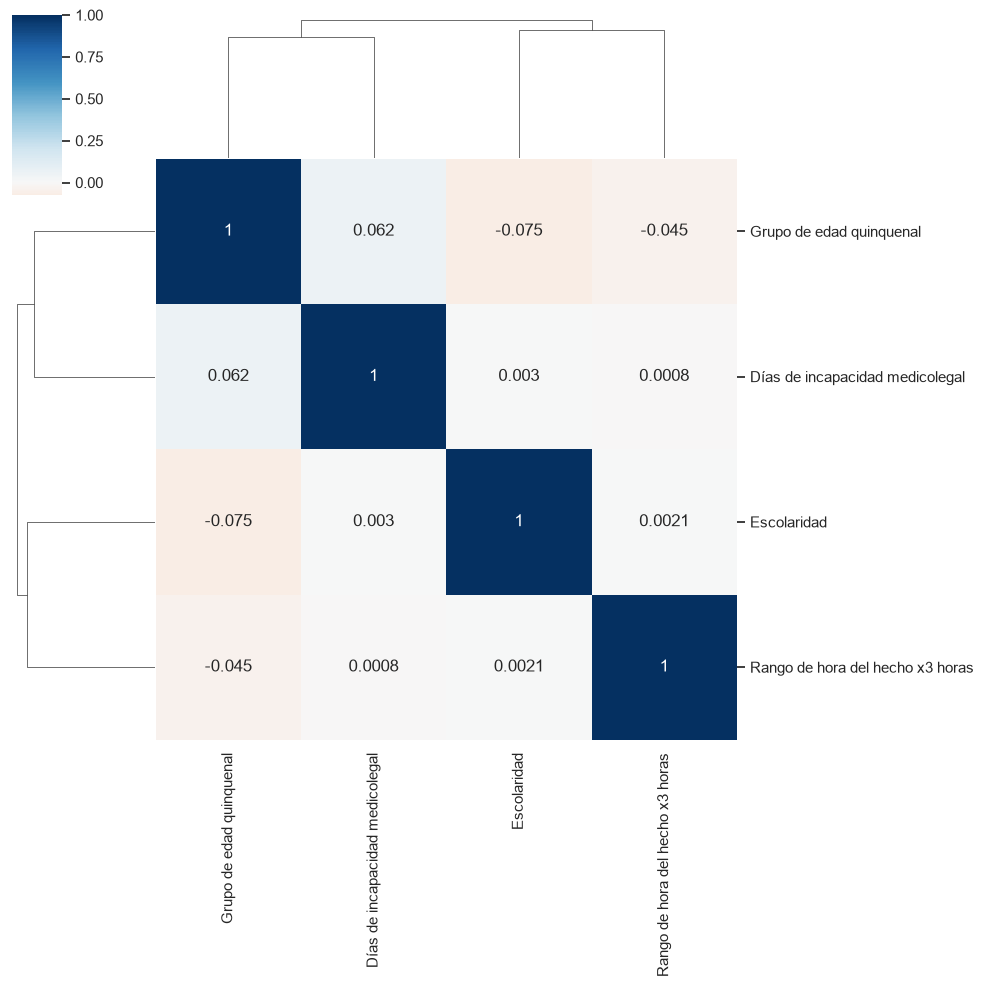

In [43]:
corr_kendall = df_lesiones[ordinales].corr(method='kendall')
corr_kendall.index = corr_kendall.columns = nombres_grafica

sns.clustermap(corr_kendall, method="complete", cmap='RdBu', annot=True, center=0)
plt.show()

Observando el gráfico, se puede apreciar que la mayoría de las correlaciones
entre las variables ordinales (`Grupo de edad quinquenal`, `Escolaridad`, `Rango de hora del hecho x3 horas`, `Días de incapacidad medicolegal`) son muy débiles, con valores absolutos muy cercanos a cero. Esto sugiere que no hay una relación monótona significativa entre estas variables.

Analisis de la **matriz de correlaciones policóricas**


In [44]:
import ordinalcorr

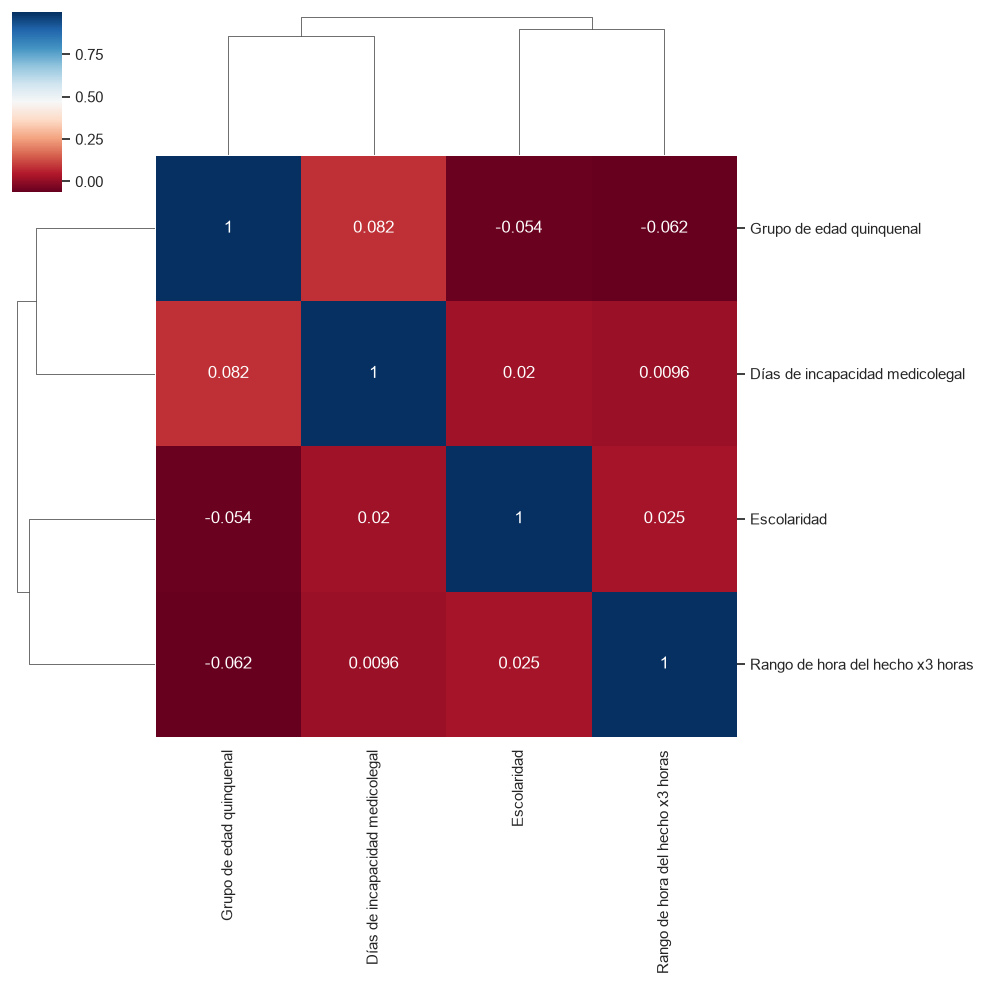

In [45]:
rho = [[ordinalcorr.polychoric(df_lesiones[x], df_lesiones[y])
        for y in ordinales] for x in ordinales]

rho_df = pd.DataFrame(rho, index=nombres_grafica, columns=nombres_grafica)

sns.clustermap(rho_df, method="complete", cmap='RdBu', annot=True)
plt.show()

El correlograma de correlaciones policóricas muestra que la asociación entre las variables ordinales ('Grupo de edad quinquenal', 'Escolaridad', 'Rango de hora del hecho x3 horas', 'Días de incapacidad medicolegal') es **débil**, con valores absolutos cercanos a cero. Esto sugiere que no hay una relación lineal fuerte entre estas variables.

Las correlaciones más altas, aunque aún bajas, se observan entre 'Grupo de edad quinquenal' y 'Días de incapacidad medicolegal' (aprox. 0.082) y entre 'Grupo de edad quinquenal' y 'Rango de hora del hecho x3 horas' (aprox. -0.062). Estos resultados refuerzan la conclusión del análisis de Kendall: las variables ordinales, de forma individual, no presentan una fuerte asociación con los días de incapacidad ni entre sí.

*Se concluye que resulta mejor para el analisis hacer la conversión de las variables ordinales en variables categoricas*

## 2.1. Transformación de las variables ordinales a variables categóricas

In [46]:
for col in ordinales:
    df_lesiones[col] = df_lesiones[col].astype(str)

In [47]:
df_lesiones.head()

,edad_q,escolar,hora,dias_incap,PaisA,PaisB,PaisC,PaisD,CivilA,CivilB,CivilC,CivilD,CivilE,CivilF,CivilG,CivilH,EtniaA,EtniaB,EtniaC,EtniaD,EtniaE,EtniaF,EtniaG,EtniaH,EtniaI,DptoA,DptoB,DptoC,DptoD,DptoE,DptoF,DptoG,DptoH,DptoI,DptoJ,DptoK,DptoL,DptoM,DptoN,DptoO,DptoP,DptoQ,DptoR,DptoS,DptoT,DptoU,DptoV,DptoW,DptoX,DptoY,DptoZ,Dptoa,Dptob,Dptoc,Dptod,Dptoe,Dptof,Dptog,Dptoh,Dptoi,Dptoj,ZonaA,ZonaB,ZonaC,ZonaD,ZonaE,EscenA,EscenB,EscenC,EscenD,EscenE,EscenF,EscenG,EscenH,EscenI,EscenJ,EscenK,EscenL,EscenM,EscenN,EscenO,EscenP,EscenQ,EscenR,EscenS,EscenT,EscenU,EscenV,EscenW,EscenX,EscenY,EscenZ,Escena,Escenb,Escenc,Escend,Escene,Escenf,Esceng,Escenh,Esceni,Escenj,Escenk,Escenl,Escenm,Escenn,Esceno,Escenp,Escenq,Escenr,Escens,Escent,Escenu,Escenv,Escenw,Escenx,ActivA,ActivB,ActivC,ActivD,ActivE,ActivF,ActivG,ActivH,ActivI,ActivJ,ActivK,ActivL,ActivM,ActivN,ActivO,ActivP,ActivQ,ActivR,ActivS,ActivT,CircunstA,CircunstB,CircunstC,CircunstD,CircunstE,CircunstF,CircunstG,MecA,MecB,MecC,MecD,MecE,MecF,MecG,MecH,MecI,MecJ,MecK,MecL,MecM,MecN,MecO,MecP,MecQ,MecR,MecS,MecT,DiagA,DiagB,DiagC,DiagD,DiagE,DiagF,DiagG,DiagH,DiagI,DiagJ,DiagK,CondA,CondB,CondC,CondD,MedioA,MedioB,MedioC,MedioD,MedioE,MedioF,MedioG,MedioH,MedioI,MedioJ,MedioK,MedioL,MedioM,MedioN,MedioO,MedioP,MedioQ,MedioR,MedioS,MedioT,MedioU,MedioV,MedioW,MedioX,MedioY,MedioZ,Medioa,Mediob,Medioc,Mediod,Medioe,Mediof,Mediog,Medioh,Medioi,Medioj,Mediok,Mediol,Mediom,Medion,Medioo,Mediop,Medioq,Medior,Medios,Mediot,Mediou,SvehA,SvehB,SvehC,SvehD,SvehE,SvehF,SvehG,SvehH,TaccA,TaccB,TaccC,TaccD,TaccE,TaccF,TaccG,TaccH,TaccI,TaccJ,TaccK,TaccL,TaccM,TaccN,TaccO,TaccP,TaccQ,TaccR,TaccS,TaccT,TaccU,ObjA,ObjB,ObjC,ObjD,ObjE,ObjF,ObjG,ObjH,ObjI,ObjJ,ObjK,SobjA,SobjB,SobjC,SobjD,SobjE,SobjF,SobjG,SobjH,SobjI,SexoA,SexoB,AnioA,AnioB,AnioC,AnioD,AnioE,AnioF,AnioG,AnioH,AnioI,AnioJ,MesA,MesB,MesC,MesD,MesE,MesF,MesG,MesH,MesI,MesJ,MesK,MesL,DiaA,DiaB,DiaC,DiaD,DiaE,DiaF,DiaG
0,6,4,2,1,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0
1,13,2,6,1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1
2,8,8,6,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
3,11,3,6,2,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [48]:
for col in ordinales:
    dicc = {}
    pref = col[:4].title()
    df_lesiones = onehot(df_lesiones, col, pref, dicc)
    diccionarios[pref] = dicc

In [49]:
df_lesiones.head()

,PaisA,PaisB,PaisC,PaisD,CivilA,CivilB,CivilC,CivilD,CivilE,CivilF,CivilG,CivilH,EtniaA,EtniaB,EtniaC,EtniaD,EtniaE,EtniaF,EtniaG,EtniaH,EtniaI,DptoA,DptoB,DptoC,DptoD,DptoE,DptoF,DptoG,DptoH,DptoI,DptoJ,DptoK,DptoL,DptoM,DptoN,DptoO,DptoP,DptoQ,DptoR,DptoS,DptoT,DptoU,DptoV,DptoW,DptoX,DptoY,DptoZ,Dptoa,Dptob,Dptoc,Dptod,Dptoe,Dptof,Dptog,Dptoh,Dptoi,Dptoj,ZonaA,ZonaB,ZonaC,ZonaD,ZonaE,EscenA,EscenB,EscenC,EscenD,EscenE,EscenF,EscenG,EscenH,EscenI,EscenJ,EscenK,EscenL,EscenM,EscenN,EscenO,EscenP,EscenQ,EscenR,EscenS,EscenT,EscenU,EscenV,EscenW,EscenX,EscenY,EscenZ,Escena,Escenb,Escenc,Escend,Escene,Escenf,Esceng,Escenh,Esceni,Escenj,Escenk,Escenl,Escenm,Escenn,Esceno,Escenp,Escenq,Escenr,Escens,Escent,Escenu,Escenv,Escenw,Escenx,ActivA,ActivB,ActivC,ActivD,ActivE,ActivF,ActivG,ActivH,ActivI,ActivJ,ActivK,ActivL,ActivM,ActivN,ActivO,ActivP,ActivQ,ActivR,ActivS,ActivT,CircunstA,CircunstB,CircunstC,CircunstD,CircunstE,CircunstF,CircunstG,MecA,MecB,MecC,MecD,MecE,MecF,MecG,MecH,MecI,MecJ,MecK,MecL,MecM,MecN,MecO,MecP,MecQ,MecR,MecS,MecT,DiagA,DiagB,DiagC,DiagD,DiagE,DiagF,DiagG,DiagH,DiagI,DiagJ,DiagK,CondA,CondB,CondC,CondD,MedioA,MedioB,MedioC,MedioD,MedioE,MedioF,MedioG,MedioH,MedioI,MedioJ,MedioK,MedioL,MedioM,MedioN,MedioO,MedioP,MedioQ,MedioR,MedioS,MedioT,MedioU,MedioV,MedioW,MedioX,MedioY,MedioZ,Medioa,Mediob,Medioc,Mediod,Medioe,Mediof,Mediog,Medioh,Medioi,Medioj,Mediok,Mediol,Mediom,Medion,Medioo,Mediop,Medioq,Medior,Medios,Mediot,Mediou,SvehA,SvehB,SvehC,SvehD,SvehE,SvehF,SvehG,SvehH,TaccA,TaccB,TaccC,TaccD,TaccE,TaccF,TaccG,TaccH,TaccI,TaccJ,TaccK,TaccL,TaccM,TaccN,TaccO,TaccP,TaccQ,TaccR,TaccS,TaccT,TaccU,ObjA,ObjB,ObjC,ObjD,ObjE,ObjF,ObjG,ObjH,ObjI,ObjJ,ObjK,SobjA,SobjB,SobjC,SobjD,SobjE,SobjF,SobjG,SobjH,SobjI,SexoA,SexoB,AnioA,AnioB,AnioC,AnioD,AnioE,AnioF,AnioG,AnioH,AnioI,AnioJ,MesA,MesB,MesC,MesD,MesE,MesF,MesG,MesH,MesI,MesJ,MesK,MesL,DiaA,DiaB,DiaC,DiaD,DiaE,DiaF,DiaG,EdadA,EdadB,EdadC,EdadD,EdadE,EdadF,EdadG,EdadH,EdadI,EdadJ,EdadK,EdadL,EdadM,EdadN,EdadO,EdadP,EdadQ,EdadR,EdadS,EscoA,EscoB,EscoC,EscoD,EscoE,EscoF,EscoG,EscoH,EscoI,EscoJ,EscoK,EscoL,HoraA,HoraB,HoraC,HoraD,HoraE,HoraF,HoraG,HoraH,HoraI,DiasA,DiasB,DiasC,DiasD
0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0

# **3. Valoración del tamaño muestral**

Para las variables cualitativas y las variables cuantitativas con pocos valores, se verifica que el tamaño de la muestra permita estimar la proporción de cada categoría con un margen de error inferior a un punto porcentual y un nivel de confianza del **99%**.

Debido a que las variables categóricas fueron transformadas mediante codificación One-Hot, cada categoría está representada por una columna cuyos valores son 0 y 1. Por lo tanto, la proporción de cada categoría se obtiene calculando el promedio de su columna, que equivale a sumar los unos y dividirlos entre el número total de observaciones.

Se evalúan todas las columnas One-Hot y se identifica la categoría cuya proporción esté más cercana al 50 %. Esta es la situación más exigente para determinar el tamaño muestral, debido a que el producto \(p(1-p)\) alcanza su máximo cuando \(p=0.5\).

Posteriormente, utilizando esta proporción crítica, un nivel de confianza del 99 % y un margen de error de 0.01, se calcula el tamaño muestral mínimo requerido y se compara con el tamaño de la muestra disponible.

---

Obtener la proporción de cada categoría

In [50]:
onehot_cols = [
    col for pref, dicc in diccionarios.items()
    for col in df_lesiones.columns
    if col.startswith(pref)
]

proporciones = df_lesiones[onehot_cols].mean()
proporciones.sort_values()

TaccU     0.000003
TaccT     0.000003
Medior    0.000003
Medioj    0.000003
MedioT    0.000003
            ...   
SobjG     0.660752
SvehF     0.663115
ActivA    0.702952
ZonaA     0.854001
PaisA     0.987021
Length: 316, dtype: float64

Encontrar la categoría más cercana al 50 %

In [51]:
distancias = (proporciones - 0.5).abs()

col_critica = distancias.idxmin()
p_critica = proporciones[col_critica]

col_critica, p_critica

('DiasB', np.float64(0.5016219559154715))

Calcular el tamaño muestral mínimo

In [52]:
conf = 0.99
alpha = 1 - conf
z_alpha = norm.ppf(1 - alpha/2)

margen_error = 0.01

n_min = np.ceil(
    (z_alpha**2 * p_critica * (1 - p_critica)) /
    margen_error**2
)

n_min

np.float64(16588.0)

In [53]:
n_muestra = len(df_lesiones)

n_muestra, n_min, n_muestra >= n_min

(342796, np.float64(16588.0), np.True_)

**Resultado**

La categoría que presentó la proporción más cercana al 50 % fue `DiasB`, con una proporción de 0.50162, equivalente al 50.16 % de las observaciones. Esta categoría representa el caso más exigente para la estimación de proporciones, ya que el término \(p(1-p)\) alcanza su máximo cuando \(p=0.5\).

Utilizando un nivel de confianza del 99 % y un margen de error máximo del 1 %, se obtuvo un tamaño muestral mínimo de 16.588 observaciones.

La base de datos cuenta con 342.796 observaciones, por lo que: \[342.796 > 16.588\]

Por tanto, se concluye que el tamaño muestral disponible cumple con el criterio mínimo establecido para las variables cualitativas y/o cuantitativas con pocos valores.

# **4. Reducción de dimensionalidad de variables binarias y nominales**

## 4.1. Extracción, limpieza y exploración básicas



### 4.1.1. Eliminación de variables redundantes

In [54]:
df_lesiones

,PaisA,PaisB,PaisC,PaisD,CivilA,CivilB,CivilC,CivilD,CivilE,CivilF,CivilG,CivilH,EtniaA,EtniaB,EtniaC,EtniaD,EtniaE,EtniaF,EtniaG,EtniaH,EtniaI,DptoA,DptoB,DptoC,DptoD,DptoE,DptoF,DptoG,DptoH,DptoI,DptoJ,DptoK,DptoL,DptoM,DptoN,DptoO,DptoP,DptoQ,DptoR,DptoS,DptoT,DptoU,DptoV,DptoW,DptoX,DptoY,DptoZ,Dptoa,Dptob,Dptoc,Dptod,Dptoe,Dptof,Dptog,Dptoh,Dptoi,Dptoj,ZonaA,ZonaB,ZonaC,ZonaD,ZonaE,EscenA,EscenB,EscenC,EscenD,EscenE,EscenF,EscenG,EscenH,EscenI,EscenJ,EscenK,EscenL,EscenM,EscenN,EscenO,EscenP,EscenQ,EscenR,EscenS,EscenT,EscenU,EscenV,EscenW,EscenX,EscenY,EscenZ,Escena,Escenb,Escenc,Escend,Escene,Escenf,Esceng,Escenh,Esceni,Escenj,Escenk,Escenl,Escenm,Escenn,Esceno,Escenp,Escenq,Escenr,Escens,Escent,Escenu,Escenv,Escenw,Escenx,ActivA,ActivB,ActivC,ActivD,ActivE,ActivF,ActivG,ActivH,ActivI,ActivJ,ActivK,ActivL,ActivM,ActivN,ActivO,ActivP,ActivQ,ActivR,ActivS,ActivT,CircunstA,CircunstB,CircunstC,CircunstD,CircunstE,CircunstF,CircunstG,MecA,MecB,MecC,MecD,MecE,MecF,MecG,MecH,MecI,MecJ,MecK,MecL,MecM,MecN,MecO,MecP,MecQ,MecR,MecS,MecT,DiagA,DiagB,DiagC,DiagD,DiagE,DiagF,DiagG,DiagH,DiagI,DiagJ,DiagK,CondA,CondB,CondC,CondD,MedioA,MedioB,MedioC,MedioD,MedioE,MedioF,MedioG,MedioH,MedioI,MedioJ,MedioK,MedioL,MedioM,MedioN,MedioO,MedioP,MedioQ,MedioR,MedioS,MedioT,MedioU,MedioV,MedioW,MedioX,MedioY,MedioZ,Medioa,Mediob,Medioc,Mediod,Medioe,Mediof,Mediog,Medioh,Medioi,Medioj,Mediok,Mediol,Mediom,Medion,Medioo,Mediop,Medioq,Medior,Medios,Mediot,Mediou,SvehA,SvehB,SvehC,SvehD,SvehE,SvehF,SvehG,SvehH,TaccA,TaccB,TaccC,TaccD,TaccE,TaccF,TaccG,TaccH,TaccI,TaccJ,TaccK,TaccL,TaccM,TaccN,TaccO,TaccP,TaccQ,TaccR,TaccS,TaccT,TaccU,ObjA,ObjB,ObjC,ObjD,ObjE,ObjF,ObjG,ObjH,ObjI,ObjJ,ObjK,SobjA,SobjB,SobjC,SobjD,SobjE,SobjF,SobjG,SobjH,SobjI,SexoA,SexoB,AnioA,AnioB,AnioC,AnioD,AnioE,AnioF,AnioG,AnioH,AnioI,AnioJ,MesA,MesB,MesC,MesD,MesE,MesF,MesG,MesH,MesI,MesJ,MesK,MesL,DiaA,DiaB,DiaC,DiaD,DiaE,DiaF,DiaG,EdadA,EdadB,EdadC,EdadD,EdadE,EdadF,EdadG,EdadH,EdadI,EdadJ,EdadK,EdadL,EdadM,EdadN,EdadO,EdadP,EdadQ,EdadR,EdadS,EscoA,EscoB,EscoC,EscoD,EscoE,EscoF,EscoG,EscoH,EscoI,EscoJ,EscoK,EscoL,HoraA,HoraB,HoraC,HoraD,HoraE,HoraF,HoraG,HoraH,HoraI,DiasA,DiasB,DiasC,DiasD
0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
1,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0
2,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0

In [55]:
df_lesiones.columns.tolist()

['PaisA',
 'PaisB',
 'PaisC',
 'PaisD',
 'CivilA',
 'CivilB',
 'CivilC',
 'CivilD',
 'CivilE',
 'CivilF',
 'CivilG',
 'CivilH',
 'EtniaA',
 'EtniaB',
 'EtniaC',
 'EtniaD',
 'EtniaE',
 'EtniaF',
 'EtniaG',
 'EtniaH',
 'EtniaI',
 'DptoA',
 'DptoB',
 'DptoC',
 'DptoD',
 'DptoE',
 'DptoF',
 'DptoG',
 'DptoH',
 'DptoI',
 'DptoJ',
 'DptoK',
 'DptoL',
 'DptoM',
 'DptoN',
 'DptoO',
 'DptoP',
 'DptoQ',
 'DptoR',
 'DptoS',
 'DptoT',
 'DptoU',
 'DptoV',
 'DptoW',
 'DptoX',
 'DptoY',
 'DptoZ',
 'Dptoa',
 'Dptob',
 'Dptoc',
 'Dptod',
 'Dptoe',
 'Dptof',
 'Dptog',
 'Dptoh',
 'Dptoi',
 'Dptoj',
 'ZonaA',
 'ZonaB',
 'ZonaC',
 'ZonaD',
 'ZonaE',
 'EscenA',
 'EscenB',
 'EscenC',
 'EscenD',
 'EscenE',
 'EscenF',
 'EscenG',
 'EscenH',
 'EscenI',
 'EscenJ',
 'EscenK',
 'EscenL',
 'EscenM',
 'EscenN',
 'EscenO',
 'EscenP',
 'EscenQ',
 'EscenR',
 'EscenS',
 'EscenT',
 'EscenU',
 'EscenV',
 'EscenW',
 'EscenX',
 'EscenY',
 'EscenZ',
 'Escena',
 'Escenb',
 'Escenc',
 'Escend',
 'Escene',
 'Escenf',
 'Esceng',


In [56]:
df_binnom = df_lesiones.copy()

In [57]:
prefijos_onehot = [
    'Pais', 'Civil', 'Etnia', 'Dpto', 'Zona', 'Escen',
    'Activ', 'Circunst', 'Mec', 'Diag', 'Cond', 'Medio',
    'Sveh', 'Tacc', 'Obj', 'Sobj',
    'Sexo', 'Anio', 'Mes', 'Dia', 'Edad', 'Esco', 'Hora', 'Dias'
]

In [58]:
columnas_drop = [prefijo + 'A' for prefijo in prefijos_onehot]
columnas_drop

['PaisA',
 'CivilA',
 'EtniaA',
 'DptoA',
 'ZonaA',
 'EscenA',
 'ActivA',
 'CircunstA',
 'MecA',
 'DiagA',
 'CondA',
 'MedioA',
 'SvehA',
 'TaccA',
 'ObjA',
 'SobjA',
 'SexoA',
 'AnioA',
 'MesA',
 'DiaA',
 'EdadA',
 'EscoA',
 'HoraA',
 'DiasA']

In [59]:
[c for c in columnas_drop if c not in df_lesiones.columns]

[]

In [60]:
df_binnom = df_lesiones.drop(columns=columnas_drop).copy()

In [61]:
df_binnom.head()

,PaisB,PaisC,PaisD,CivilB,CivilC,CivilD,CivilE,CivilF,CivilG,CivilH,EtniaB,EtniaC,EtniaD,EtniaE,EtniaF,EtniaG,EtniaH,EtniaI,DptoB,DptoC,DptoD,DptoE,DptoF,DptoG,DptoH,DptoI,DptoJ,DptoK,DptoL,DptoM,DptoN,DptoO,DptoP,DptoQ,DptoR,DptoS,DptoT,DptoU,DptoV,DptoW,DptoX,DptoY,DptoZ,Dptoa,Dptob,Dptoc,Dptod,Dptoe,Dptof,Dptog,Dptoh,Dptoi,Dptoj,ZonaB,ZonaC,ZonaD,ZonaE,EscenB,EscenC,EscenD,EscenE,EscenF,EscenG,EscenH,EscenI,EscenJ,EscenK,EscenL,EscenM,EscenN,EscenO,EscenP,EscenQ,EscenR,EscenS,EscenT,EscenU,EscenV,EscenW,EscenX,EscenY,EscenZ,Escena,Escenb,Escenc,Escend,Escene,Escenf,Esceng,Escenh,Esceni,Escenj,Escenk,Escenl,Escenm,Escenn,Esceno,Escenp,Escenq,Escenr,Escens,Escent,Escenu,Escenv,Escenw,Escenx,ActivB,ActivC,ActivD,ActivE,ActivF,ActivG,ActivH,ActivI,ActivJ,ActivK,ActivL,ActivM,ActivN,ActivO,ActivP,ActivQ,ActivR,ActivS,ActivT,CircunstB,CircunstC,CircunstD,CircunstE,CircunstF,CircunstG,MecB,MecC,MecD,MecE,MecF,MecG,MecH,MecI,MecJ,MecK,MecL,MecM,MecN,MecO,MecP,MecQ,MecR,MecS,MecT,DiagB,DiagC,DiagD,DiagE,DiagF,DiagG,DiagH,DiagI,DiagJ,DiagK,CondB,CondC,CondD,MedioB,MedioC,MedioD,MedioE,MedioF,MedioG,MedioH,MedioI,MedioJ,MedioK,MedioL,MedioM,MedioN,MedioO,MedioP,MedioQ,MedioR,MedioS,MedioT,MedioU,MedioV,MedioW,MedioX,MedioY,MedioZ,Medioa,Mediob,Medioc,Mediod,Medioe,Mediof,Mediog,Medioh,Medioi,Medioj,Mediok,Mediol,Mediom,Medion,Medioo,Mediop,Medioq,Medior,Medios,Mediot,Mediou,SvehB,SvehC,SvehD,SvehE,SvehF,SvehG,SvehH,TaccB,TaccC,TaccD,TaccE,TaccF,TaccG,TaccH,TaccI,TaccJ,TaccK,TaccL,TaccM,TaccN,TaccO,TaccP,TaccQ,TaccR,TaccS,TaccT,TaccU,ObjB,ObjC,ObjD,ObjE,ObjF,ObjG,ObjH,ObjI,ObjJ,ObjK,SobjB,SobjC,SobjD,SobjE,SobjF,SobjG,SobjH,SobjI,SexoB,AnioB,AnioC,AnioD,AnioE,AnioF,AnioG,AnioH,AnioI,AnioJ,MesB,MesC,MesD,MesE,MesF,MesG,MesH,MesI,MesJ,MesK,MesL,DiaB,DiaC,DiaD,DiaE,DiaF,DiaG,EdadB,EdadC,EdadD,EdadE,EdadF,EdadG,EdadH,EdadI,EdadJ,EdadK,EdadL,EdadM,EdadN,EdadO,EdadP,EdadQ,EdadR,EdadS,EscoB,EscoC,EscoD,EscoE,EscoF,EscoG,EscoH,EscoI,EscoJ,EscoK,EscoL,HoraB,HoraC,HoraD,HoraE,HoraF,HoraG,HoraH,HoraI,DiasB,DiasC,DiasD
0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0
3,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,

### 4.1.2. Matriz de correlaciones

Para identificar un grupo de variables adecuado para la reducción de dimensionalidad, se analiza la asociación entre las variables binarias mediante la correlación de Pearson. Esto permite identificar grupos de variables que presentan relaciones relativamente fuertes entre sí.

In [62]:
cor_bin = df_binnom.corr()
cor_bin.head()

,PaisB,PaisC,PaisD,CivilB,CivilC,CivilD,CivilE,CivilF,CivilG,CivilH,EtniaB,EtniaC,EtniaD,EtniaE,EtniaF,EtniaG,EtniaH,EtniaI,DptoB,DptoC,DptoD,DptoE,DptoF,DptoG,DptoH,DptoI,DptoJ,DptoK,DptoL,DptoM,DptoN,DptoO,DptoP,DptoQ,DptoR,DptoS,DptoT,DptoU,DptoV,DptoW,DptoX,DptoY,DptoZ,Dptoa,Dptob,Dptoc,Dptod,Dptoe,Dptof,Dptog,Dptoh,Dptoi,Dptoj,ZonaB,ZonaC,ZonaD,ZonaE,EscenB,EscenC,EscenD,EscenE,EscenF,EscenG,EscenH,EscenI,EscenJ,EscenK,EscenL,EscenM,EscenN,EscenO,EscenP,EscenQ,EscenR,EscenS,EscenT,EscenU,EscenV,EscenW,EscenX,EscenY,EscenZ,Escena,Escenb,Escenc,Escend,Escene,Escenf,Esceng,Escenh,Esceni,Escenj,Escenk,Escenl,Escenm,Escenn,Esceno,Escenp,Escenq,Escenr,Escens,Escent,Escenu,Escenv,Escenw,Escenx,ActivB,ActivC,ActivD,ActivE,ActivF,ActivG,ActivH,ActivI,ActivJ,ActivK,ActivL,ActivM,ActivN,ActivO,ActivP,ActivQ,ActivR,ActivS,ActivT,CircunstB,CircunstC,CircunstD,CircunstE,CircunstF,CircunstG,MecB,MecC,MecD,MecE,MecF,MecG,MecH,MecI,MecJ,MecK,MecL,MecM,MecN,MecO,MecP,MecQ,MecR,MecS,MecT,DiagB,DiagC,DiagD,DiagE,DiagF,DiagG,DiagH,DiagI,DiagJ,DiagK,CondB,CondC,CondD,MedioB,MedioC,MedioD,MedioE,MedioF,MedioG,MedioH,MedioI,MedioJ,MedioK,MedioL,MedioM,MedioN,MedioO,MedioP,MedioQ,MedioR,MedioS,MedioT,MedioU,MedioV,MedioW,MedioX,MedioY,MedioZ,Medioa,Mediob,Medioc,Mediod,Medioe,Mediof,Mediog,Medioh,Medioi,Medioj,Mediok,Mediol,Mediom,Medion,Medioo,Mediop,Medioq,Medior,Medios,Mediot,Mediou,SvehB,SvehC,SvehD,SvehE,SvehF,SvehG,SvehH,TaccB,TaccC,TaccD,TaccE,TaccF,TaccG,TaccH,TaccI,TaccJ,TaccK,TaccL,TaccM,TaccN,TaccO,TaccP,TaccQ,TaccR,TaccS,TaccT,TaccU,ObjB,ObjC,ObjD,ObjE,ObjF,ObjG,ObjH,ObjI,ObjJ,ObjK,SobjB,SobjC,SobjD,SobjE,SobjF,SobjG,SobjH,SobjI,SexoB,AnioB,AnioC,AnioD,AnioE,AnioF,AnioG,AnioH,AnioI,AnioJ,MesB,MesC,MesD,MesE,MesF,MesG,MesH,MesI,MesJ,MesK,MesL,DiaB,DiaC,DiaD,DiaE,DiaF,DiaG,EdadB,EdadC,EdadD,EdadE,EdadF,EdadG,EdadH,EdadI,EdadJ,EdadK,EdadL,EdadM,EdadN,EdadO,EdadP,EdadQ,EdadR,EdadS,EscoB,EscoC,EscoD,EscoE,EscoF,EscoG,EscoH,EscoI,EscoJ,EscoK,EscoL,HoraB,HoraC,HoraD,HoraE,HoraF,HoraG,HoraH,HoraI,DiasB,DiasC,DiasD
PaisB,1.000000,-0.002749,-0.000745,0.008398,0.000562,-0.000449,-0.001941,0.001487,-0.009106,-0.002797,-0.003065,-0.000213,-0.000204,0.003241,-0.000131,-0.001403,-0.001536,0.003187,0.001389,-0.001891,0.007732,-0.004365,-0.004697,0.003301,-0.000067,-0.000192,-0.001695,-0.002344,-0.003458,-0.001788,-0.001127,-0.002025,-0.002590,-0.000200,-0.000673,-0.000755,-0.001804,-0.001846,0.000747,-0.003362,-0.003490,-0.003141,-0.001547,0.004281,0.009854,0.009231,-0.000682,-0.000332,0.000913,-0.002059,0.009114,-0.000222,-0.000447,-0.001113,0.001052,-0.002450,-0.002322,-0.001666,0.000818,-0.000465,-0.000473,-0.000200,-0.000097,-0.000292,0.008237,-0.000097,-0.000180,-0.000317,-0.000302,-0.000292,-0.000087,-0.000243,-0.000218,-0.000346,-0.000320,-0.000163,-0.000115,-0.000044,-0.000235,-0.000157,-0.000209,-0.000200,-0.000151,-0.000514,0.004897,-0.000627,-0.000044,-0.000075,-0.001197,-0.001812,-0.000174,-0.000649,-0.000519,-0.000107,-0.000157,-0.000541,-0.000349,-0.001399,-0.000884,0.001159,-0.000151,-0.000157,-0.000131,0.001559,-0.000802,-0.000580,0.000326,-0.000265,-0.001167,-0.000299,0.001113,-0.002549,-0.002517,-0.000663,-0.000210,-0.000835,-0.000420,-0.000138,-0.000062,-0.000123,-0.000131,-0.000247,-0.000123,-0.000208,-0.001931,-0.001125,0.003402,-0.000163,0.002348,-0.002474,-0.001396,-0.000115,-0.000044,-0.000131,-0.000180,0.000586,-0.000123,-0.000529,0.001115,-0.001418,-0.000332,-0.000180,-0.000062,-0.000062,-0.000073,-0.000062,0.000258,-0.000131,-0.000601,-0.000131,0.001714,-0.000396,0.002433,0.003103,-0.001114,0.005980,-0.004513,0.000291,0.001353,-0.001504,0.004410,0.000307,-0.000357,-0.000399,0.004275,-0.000115,-0.000413,0.013216,-0.000075,-0.000115,0.002061,0.000744,0.000272,0.002905,-0.001434,-0.000556,-0.000568,0.000313,-0.000097,-0.000272,-0.000087,-0.000044,-0.000138,-0.000174,-0.000425,0.002177,0.000500,-0.008724,-0.000760,-0.000737,0.001132,-0.000505,-0.000062,-0.002428,-0.000209,-0.000107,-0.000115,-0.000044,-0.001008,-0.000555,-0.000

In [63]:
cor_bin_a = cor_bin.abs()

### 4.1.3. Identificación de grupos de variables asociadas

Se utiliza un mapa de calor con agrupamiento jerárquico para visualizar las asociaciones entre las variables. El dendrograma permite identificar grupos de variables que presentan mayores niveles de correlación entre sí. A partir de estos grupos se seleccionará un subconjunto de variables para realizar el análisis de correspondencias múltiples.

c:\Users\danSo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\danSo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


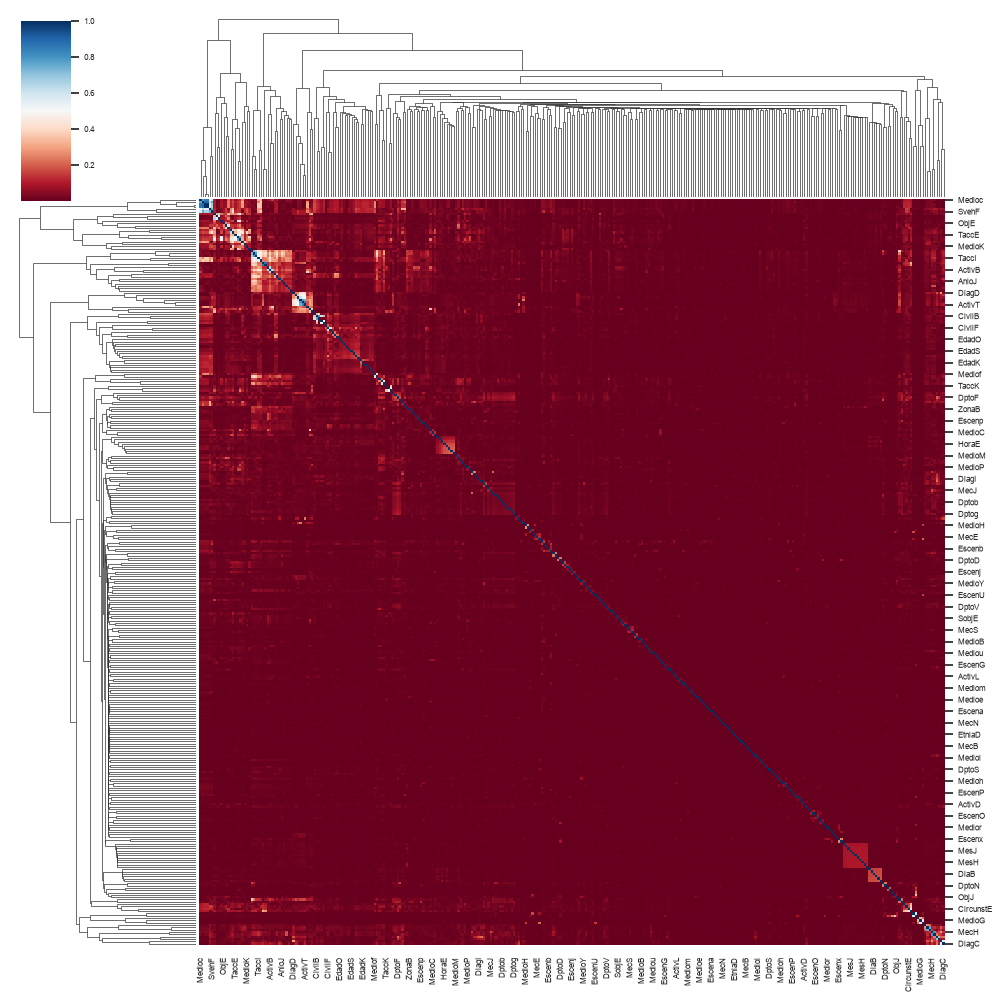

In [64]:
sns.set(font_scale=0.5)
sns.clustermap(cor_bin_a, method="complete", cmap="RdBu", annot=False)
plt.show()

### 4.1.4. Elaboración de subgrupos asociados

c:\Users\danSo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\danSo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


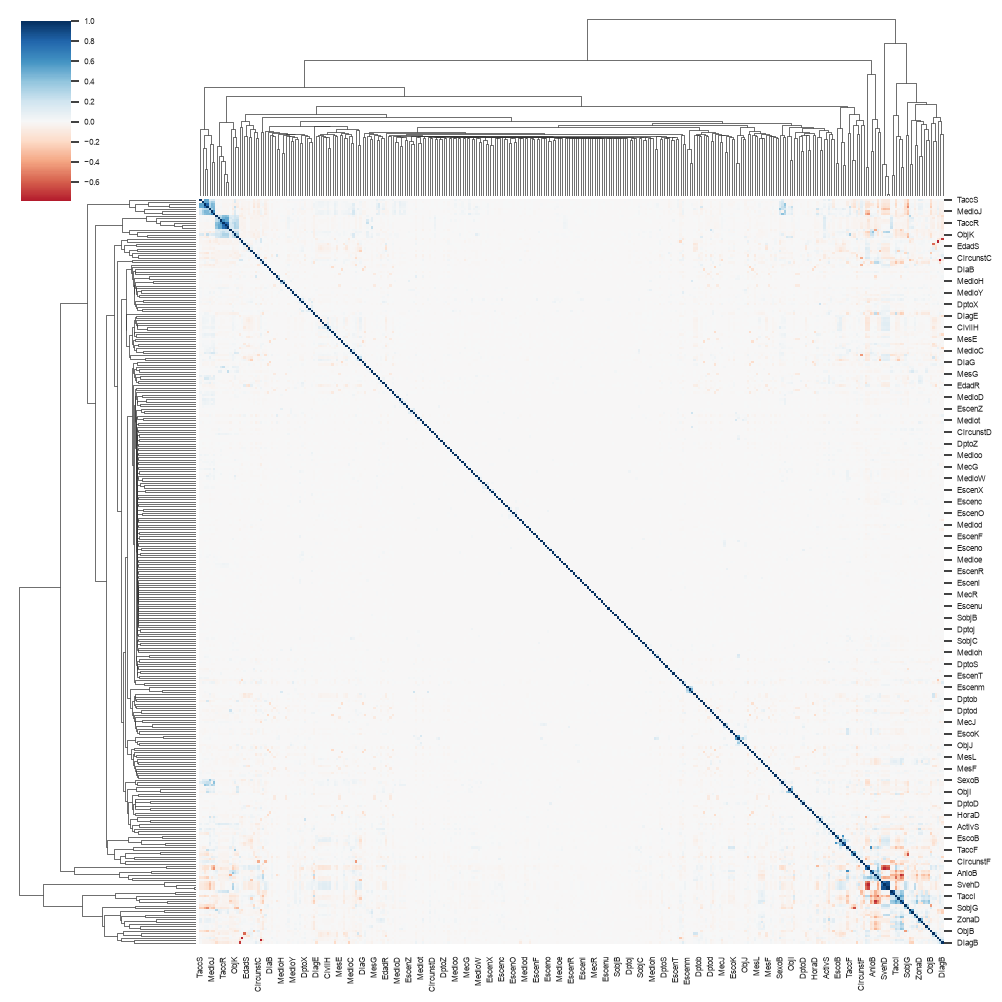

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Usar la MATRIZ DE CORRELACIÓN
g = sns.clustermap(cor_bin, method="complete", cmap='RdBu', center=0, annot=False)

# 2. Extraer el nuevo orden de los índices
re = g.dendrogram_row.reordered_ind

# 3. Reordenar la matriz de correlación según el dendrograma
cor_nueva = cor_bin.iloc[re, re].copy()

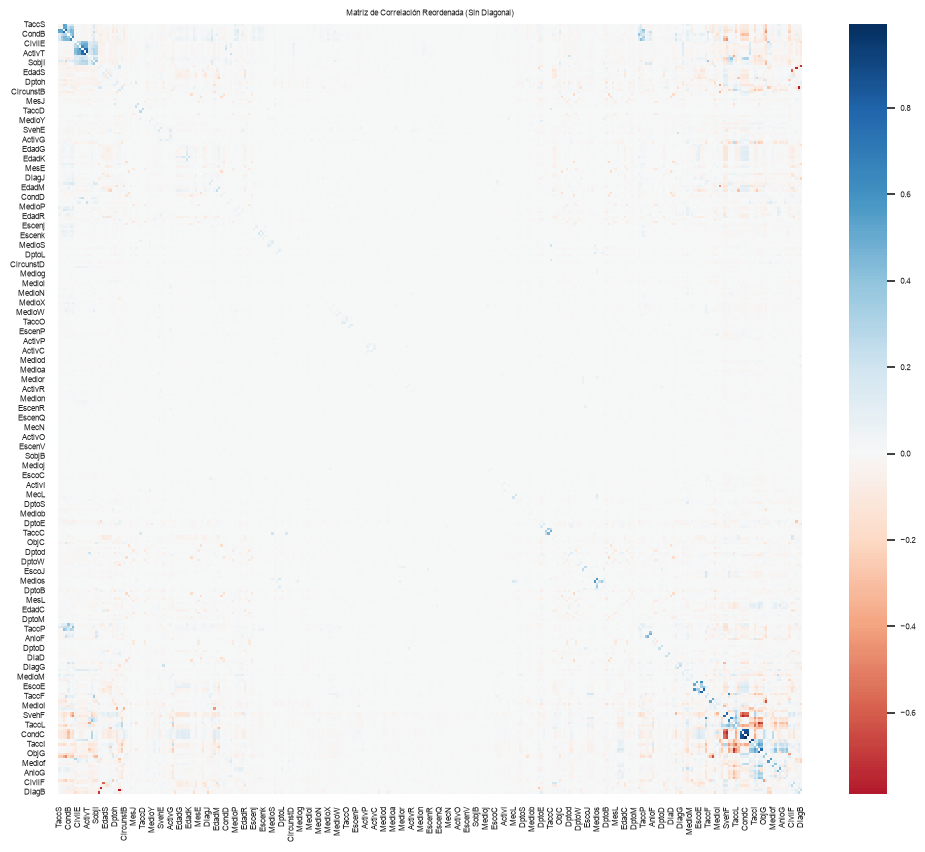

In [66]:
# Reemplazar la diagonal principal por 0
import numpy as np

for i in cor_nueva.index:
    cor_nueva.loc[i, i] = 0

# Graficar para inspeccionar visualmente la nueva estructura
plt.figure(figsize=(12, 10))
sns.heatmap(cor_nueva, cmap='RdBu', center=0)
plt.title("Matriz de Correlación Reordenada (Sin Diagonal)")
plt.show()

In [67]:
import numpy as np

# 1. Calcular la suma de correlaciones absolutas
suma_cor = cor_nueva.abs().sum(axis=1).sort_values()

# 2. Calcular sugerencias analíticas automáticamente
percentil_15 = np.percentile(suma_cor, 15)
codo_sugerido = 1.0  # Punto de inflexión visual observado en la curva

# 3. Definir y mostrar el umbral final
UMBRAL = codo_sugerido  # O puedes asignar 'percentil_15' si prefieres

print(f"--- EVALUACIÓN DE UMBRALES ---")
print(f"Sugerencia por Percentil 15% : {percentil_15:.2f}")
print(f"Sugerencia por Regla del Codo: {codo_sugerido:.2f}")
print(f"-> UMBRAL SELECCIONADO: {UMBRAL}")

--- EVALUACIÓN DE UMBRALES ---
Sugerencia por Percentil 15% : 0.47
Sugerencia por Regla del Codo: 1.00
-> UMBRAL SELECCIONADO: 1.0


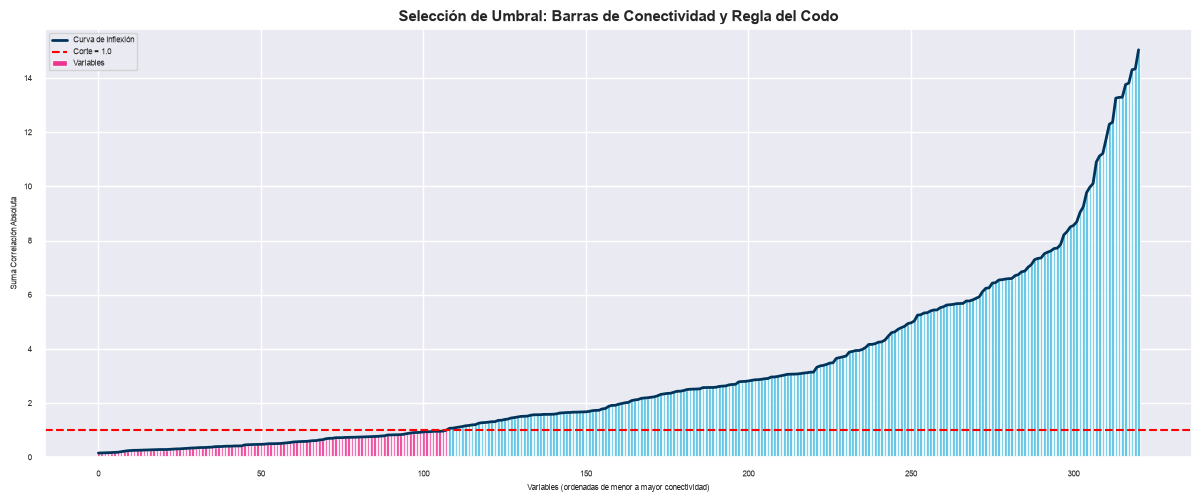

Variables retenidas: 213 de 321 (Descartadas: 108)


In [68]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calcular suma de correlaciones absolutas
suma_cor = cor_nueva.abs().sum(axis=1).sort_values()
UMBRAL = 1.0

# 2. Graficar barras + curva del codo en una sola figura
plt.figure(figsize=(12, 5))

# Diagrama de barras con color condicional
colores = ['#EC0677' if val < UMBRAL else '#22b2de' for val in suma_cor.values]
plt.bar(range(len(suma_cor)), suma_cor.values, color=colores, width=0.8, alpha=0.8, label='Variables')

# Línea de tendencia (curva del codo)
plt.plot(range(len(suma_cor)), suma_cor.values, color='#00345b', lw=2, label='Curva de Inflexión')

# Línea horizontal del umbral
plt.axhline(y=UMBRAL, color='red', ls='--', lw=1.5, label=f'Corte = {UMBRAL}')

plt.title("Selección de Umbral: Barras de Conectividad y Regla del Codo", fontsize=11, fontweight='bold')
plt.xlabel("Variables (ordenadas de menor a mayor conectividad)")
plt.ylabel("Suma Correlación Absoluta")
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

# 3. Filtrar variables retenidas
variables_relevantes = suma_cor[suma_cor >= UMBRAL].index.tolist()
print(f"Variables retenidas: {len(variables_relevantes)} de {len(suma_cor)} (Descartadas: {len(suma_cor) - len(variables_relevantes)})")

c:\Users\danSo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
c:\Users\danSo\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


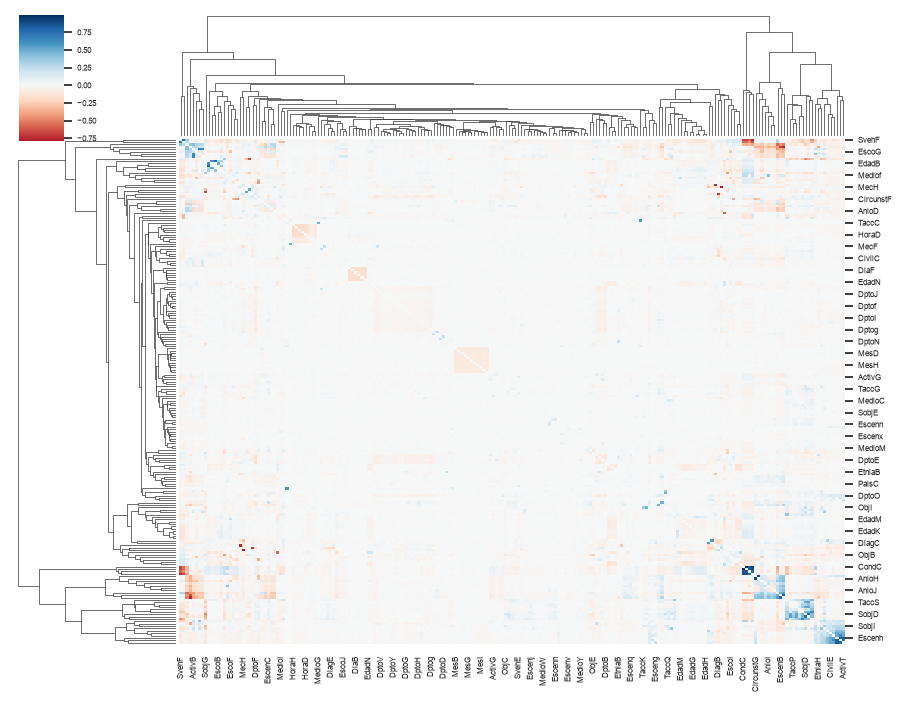


=== Subgrupo 1 (71 variables) ===
SvehF, MedioZ, TaccL, EtniaI, ActivB, EscoG, AnioB, Escenr, SobjG, CivilB, EdadB, EdadL, EscoB, EscoE, ObjG, Mediof, EscoF, CircunstB, CircunstE, DiasC, MecH, ObjD, SobjH, DiagH, DptoF, CircunstF, AnioF, AnioE, EscenC, AnioC, AnioD, CivilG, MedioI, MedioF, EscenH, TaccC, HoraH, HoraG, HoraF, HoraE, HoraD, HoraI, HoraB, HoraC, MedioG, MecF, DiagG, DiagI, DiagE, DiagJ, CivilC, Dptoa, EscoJ, EscoK, DiaG, DiaF, DiaB, DiaC, DiaE, DiaD, EdadN, EdadO, Dptoc, DptoX, DptoV, DptoJ, DptoZ, DptoC, DptoY, DptoM, Dptof

=== Subgrupo 2 (71 variables) ===
DptoU, DptoG, DptoL, Dptob, DptoI, DptoH, DptoK, DptoW, DptoT, Dptog, DptoP, ActivF, EtniaE, DptoD, DptoN, SobjF, ObjJ, MesB, MesC, MesD, MesE, MesG, MesF, MesL, MesH, MesI, MesK, MesJ, Escenp, ActivG, ActivJ, ZonaC, ActivS, ObjC, TaccG, MedioP, MedioL, SvehE, MecJ, MedioC, MedioX, Escenj, TaccH, MedioN, SobjE, MedioW, MedioO, MedioE, Escenk, Escenn, PaisD, DptoR, ActivK, Escenv, Escenx, MecI, ActivD, MedioY, Medioo

In [69]:
import seaborn as sns, matplotlib.pyplot as plt, pandas as pd

# 1. Clustermap final y extracción del nuevo orden de variables
corr_filtrada = cor_nueva.loc[variables_relevantes, variables_relevantes]
g = sns.clustermap(corr_filtrada, method="complete", cmap='RdBu', center=0, figsize=(9, 7))
plt.show()

orden = [corr_filtrada.columns[i] for i in g.dendrogram_col.reordered_ind]

# 2. Partición en 3 subgrupos
k = len(orden) // 3
subgrupos = {
    "Subgrupo 1": orden[:k],
    "Subgrupo 2": orden[k:2*k],
    "Subgrupo 3": orden[2*k:]
}

# 3. Imprimir variables especificas por grupo
for nombre, vars_g in subgrupos.items():
    print(f"\n=== {nombre} ({len(vars_g)} variables) ===")
    print(", ".join(vars_g))

In [70]:
corr_filtrada.shape

(213, 213)

In [71]:
dfs_subgrupos = {
    nombre: df_binnom[vars_g].copy()
    for nombre, vars_g in subgrupos.items()
}

df_subgrupo1 = dfs_subgrupos["Subgrupo 1"]
df_subgrupo2 = dfs_subgrupos["Subgrupo 2"]
df_subgrupo3 = dfs_subgrupos["Subgrupo 3"]

## 4.2. Analisis de Correlaciones Multiples (MCA)

### 4.2.1 Ajustar MCA

In [72]:
%pip install prince
import prince

Note: you may need to restart the kernel to use updated packages.


In [73]:
import prince

def hacer_mca(df):
    mca = prince.MCA(
        n_components=20,
        n_iter=5,
        random_state=42
    )
    return mca.fit(df)

mca1 = hacer_mca(df_subgrupo1)
mca2 = hacer_mca(df_subgrupo2)
mca3 = hacer_mca(df_subgrupo3)

In [74]:
print(mca1)
print(mca2)
print(mca3)

MCA(n_components=20, n_iter=5, random_state=42)
MCA(n_components=20, n_iter=5, random_state=42)
MCA(n_components=20, n_iter=5, random_state=42)


### 4.2.2 Comparación de inercia en los 3 subgrupos

In [75]:
print("SUBGRUPO 1")
print(mca1.eigenvalues_summary)

print("\nSUBGRUPO 2")
print(mca2.eigenvalues_summary)

print("\nSUBGRUPO 3")
print(mca3.eigenvalues_summary)

SUBGRUPO 1
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.040         4.03%                      4.03%
1              0.036         3.56%                      7.59%
2              0.032         3.24%                     10.84%
3              0.027         2.70%                     13.54%
4              0.025         2.47%                     16.01%
5              0.022         2.22%                     18.22%
6              0.021         2.13%                     20.35%
7              0.021         2.08%                     22.43%
8              0.021         2.06%                     24.49%
9              0.019         1.94%                     26.43%
10             0.019         1.85%                     28.28%
11             0.018         1.84%                     30.12%
12             0.018         1.79%                     31.91%
13             0.017         1.70%                     33.6

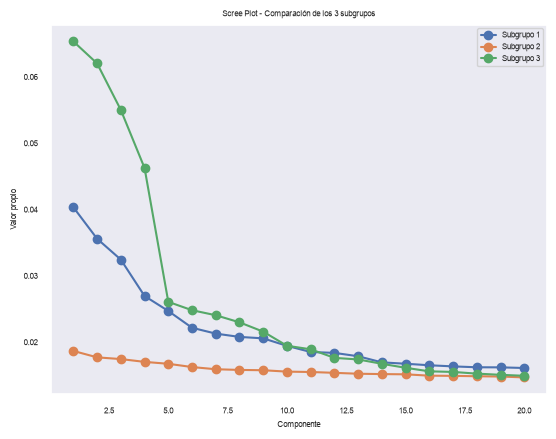

In [76]:
import matplotlib.pyplot as plt

plt.plot(range(1, 21), mca1.eigenvalues_, marker='o', label='Subgrupo 1')
plt.plot(range(1, 21), mca2.eigenvalues_, marker='o', label='Subgrupo 2')
plt.plot(range(1, 21), mca3.eigenvalues_, marker='o', label='Subgrupo 3')

plt.xlabel("Componente")
plt.ylabel("Valor propio")
plt.title("Scree Plot - Comparación de los 3 subgrupos")
plt.legend()
plt.grid()
plt.show()

### 4.2.3 Contribución de las categórias para las primeras 6 dimensiones

In [77]:
for nombre, mca in [
    ("Subgrupo 1", mca1),
    ("Subgrupo 2", mca2),
    ("Subgrupo 3", mca3)
]:
    print(f"\n{nombre}")
    
    contrib = mca.column_contributions_
    
    for d in range(6):
        top5 = contrib[d].sort_values(ascending=False).head(5).sum()
        print(f"Dimensión {d+1}: {top5:.3f} ({top5*100:.2f}%)")


Subgrupo 1
Dimensión 1: 0.387 (38.66%)
Dimensión 2: 0.531 (53.14%)
Dimensión 3: 0.680 (68.01%)
Dimensión 4: 0.445 (44.50%)
Dimensión 5: 0.468 (46.83%)
Dimensión 6: 0.541 (54.13%)

Subgrupo 2
Dimensión 1: 0.837 (83.72%)
Dimensión 2: 0.688 (68.76%)
Dimensión 3: 0.747 (74.71%)
Dimensión 4: 0.710 (70.97%)
Dimensión 5: 0.524 (52.43%)
Dimensión 6: 0.664 (66.40%)

Subgrupo 3
Dimensión 1: 0.484 (48.42%)
Dimensión 2: 0.475 (47.47%)
Dimensión 3: 0.274 (27.39%)
Dimensión 4: 0.276 (27.64%)
Dimensión 5: 0.706 (70.60%)
Dimensión 6: 0.651 (65.14%)


In [78]:
# 5 Categorías más representativas por dimensión 
for nombre, mca in [
    ("Subgrupo 1", mca1),
    ("Subgrupo 2", mca2),
    ("Subgrupo 3", mca3)
]:
    print(f"\n===== {nombre} =====")
    contrib = mca.column_contributions_

    for d in range(6):
        top5 = contrib[d].sort_values(ascending=False).head(5)
        print(f"\nDimensión {d+1}")
        for cat, valor in top5.items():
            print(f"{cat}: {valor*100:.2f}%")


===== Subgrupo 1 =====

Dimensión 1
TaccL__1: 11.45%
SvehF__0: 7.22%
CivilB__1: 7.20%
ActivB__1: 6.85%
TaccL__0: 5.94%

Dimensión 2
CivilB__1: 16.31%
ActivB__1: 12.28%
EdadL__1: 9.92%
Escenr__1: 7.52%
EscoE__1: 7.11%

Dimensión 3
SobjH__1: 20.02%
SobjG__0: 17.06%
ObjD__1: 14.57%
SobjG__1: 8.76%
ObjG__1: 7.60%

Dimensión 4
CivilB__1: 12.56%
SvehF__0: 9.00%
MedioZ__0: 8.67%
EdadB__1: 7.80%
MedioZ__1: 6.46%

Dimensión 5
AnioD__1: 13.08%
EscenC__1: 9.71%
EtniaI__0: 9.27%
EtniaI__1: 8.08%
AnioC__1: 6.69%

Dimensión 6
MecF__1: 16.83%
DiagG__1: 11.69%
MedioF__1: 10.47%
MecH__0: 7.94%
DiagH__1: 7.20%

===== Subgrupo 2 =====

Dimensión 1
EtniaB__1: 40.94%
Dptoh__1: 19.51%
DptoN__1: 18.10%
Dptoh__0: 2.61%
DptoG__1: 2.56%

Dimensión 2
DptoE__1: 24.21%
EtniaE__1: 12.04%
ActivJ__1: 11.53%
DptoD__1: 10.74%
MedioY__1: 10.24%

Dimensión 3
DptoP__1: 28.34%
ActivF__1: 24.53%
EtniaE__1: 9.32%
DptoD__1: 8.75%
ObjE__1: 3.77%

Dimensión 4
DptoD__1: 21.84%
EtniaE__1: 19.01%
ActivF__1: 12.45%
DptoP__1: 11.64

### 4.2.4 Renombre de variables categóricas

In [79]:
def renombrar_categoria(x):
    base, presencia = x.rsplit("__", 1)
    prefijo = base[:-1]
    codigo = base[-1]

    if prefijo in diccionarios and codigo in diccionarios[prefijo]:
        nombre = diccionarios[prefijo][codigo]
    else:
        nombre = f"código {codigo}"

    estado = "presente" if presencia == "1" else "ausente"

    return f"{prefijo}: {nombre} ({estado})"

In [80]:
filas = []

for nombre, mca, df in [
    ("Subgrupo 1", mca1, df_subgrupo1),
    ("Subgrupo 2", mca2, df_subgrupo2),
    ("Subgrupo 3", mca3, df_subgrupo3)
]:
    contrib = mca.column_contributions_
    coord = mca.column_coordinates(df)

    for d in range(6):
        top = contrib[d].sort_values(ascending=False).head(5)

        for cat in top.index:
            filas.append([
                nombre,
                d + 1,
                renombrar_categoria(cat),
                contrib.loc[cat, d] * 100,
                coord.loc[cat, d]
            ])

tabla_mca = pd.DataFrame(
    filas,
    columns=["Subgrupo", "Dimensión", "Categoría",
             "Contribución (%)", "Coordenada"]
)

tabla_mca

,Subgrupo,Dimensión,Categoría,Contribución (%),Coordenada
0,Subgrupo 1,1,Tacc: Choque con otro vehículo (presente),11.454181,-0.980181
1,Subgrupo 1,1,Sveh: Particular (ausente),7.216232,0.783324
2,Subgrupo 1,1,Civil: No aplica (presente),7.198587,2.543654
3,Subgrupo 1,1,Activ: Actividades de desplazamiento de un lug...,6.849910,-0.885796
4,Subgrupo 1,1,Tacc: Choque con otro vehículo (ausente),5.940492,0.508352
...,...,...,...,...,...
85,Subgrupo 3,6,Obj: Objeto fijo (presente),25.486905,5.285735
86,Subgrupo 3,6,Tacc: Choque con objeto fijo (presente),14.225882,8.310976
87,Subgrupo 3,6,Tacc: Choque con objeto fijo o en movimiento (...,9.371255,8.613095
88,Subgrupo 3,6,Zona: Parte rural (vereda y campo) (presente),8.543434,1.421022


In [84]:
tabla_mca["Categoría"] = tabla_mca["Categoría"].apply(
    lambda x: x.replace(" (presente)", " [PRESENCIA]")
              .replace(" (ausente)", " [AUSENCIA]")
)

In [86]:
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

tabla_mca

,Subgrupo,Dimensión,Categoría,Contribución (%),Coordenada
0,Subgrupo 1,1,Tacc: Choque con otro vehículo [PRESENCIA],11.454181,-0.980181
1,Subgrupo 1,1,Sveh: Particular [AUSENCIA],7.216232,0.783324
2,Subgrupo 1,1,Civil: No aplica [PRESENCIA],7.198587,2.543654
3,Subgrupo 1,1,Activ: Actividades de desplazamiento de un lugar a otro. [PRESENCIA],6.849910,-0.885796
4,Subgrupo 1,1,Tacc: Choque con otro vehículo [AUSENCIA],5.940492,0.508352
5,Subgrupo 1,2,Civil: No aplica [PRESENCIA],16.308880,3.596341
6,Subgrupo 1,2,Activ: Actividades de desplazamiento de un lugar a otro. [PRESENCIA],12.275188,1.113832
7,Subgrupo 1,2,Edad: 2 [PRESENCIA],9.921665,3.539631
8,Subgrupo 1,2,"Escen: Vía pública, calle, carretera [PRESENCIA]",7.517984,1.216950
9,Subgrupo 1,2,Esco: 2 [PRESENCIA],7.114473,1.338291


### 4.2.5 Analisis de Dimensiones MCA

#### 4.2.5.1. Subgrupo 1

**Interpretación de la Dimensión 1**

La primera dimensión del Subgrupo 1 presenta como categorías con mayor contribución la **presencia de “Choque con otro vehículo” (11,45%)**, la **ausencia de “Vehículo particular” (7,22%)**, la **presencia de “Civil: No aplica” (7,20%)**, la **presencia de actividades de desplazamiento de un lugar a otro (6,85%)** y la **ausencia de “Choque con otro vehículo” (5,94%)**.

Al analizar las coordenadas, se observa un contraste entre ambos lados del eje. En el lado negativo se encuentran principalmente la presencia de “Choque con otro vehículo” y la presencia de actividades de desplazamiento de un lugar a otro. En el lado positivo se ubican la presencia de “Civil: No aplica”, la ausencia de “Vehículo particular” y la ausencia de “Choque con otro vehículo”.

Por lo tanto, esta dimensión permite diferenciar principalmente **patrones relacionados con el tipo de accidente, la actividad realizada y determinadas características del vehículo o condición civil**. Las categorías ubicadas en lados opuestos representan perfiles diferenciados dentro de los registros analizados.

Esta interpretación corresponde a asociaciones estadísticas entre categorías y no implica relaciones causales.

**Interpretación de la Dimensión 2**

La segunda dimensión del Subgrupo 1 está principalmente determinada por la **presencia de “Civil: No aplica” (16,31%)**, la **presencia de actividades de desplazamiento de un lugar a otro (12,28%)**, la **presencia de la categoría de edad 2 (9,92%)**, la **presencia de “Vía pública, calle, carretera” (7,52%)** y la **presencia de escolaridad 2 (7,11%)**.

Las categorías presentan coordenadas positivas, destacándose “Civil: No aplica” (3,60) y “Edad: 2” (3,54) por su distancia respecto al origen. Esto indica que estas categorías tienen una participación importante en la diferenciación de los perfiles representados por esta dimensión.

En conjunto, la dimensión parece estar relacionada con un **patrón caracterizado por condiciones sociodemográficas y contextuales del evento**, especialmente la edad, escolaridad, actividad realizada y escenario del hecho. La dimensión permite distinguir registros que presentan conjuntamente estas características de aquellos que se encuentran en posiciones diferentes del espacio factorial.

Las asociaciones identificadas son de carácter estadístico y no deben interpretarse como relaciones causales.

**Interpretación de la Dimensión 3**

La tercera dimensión del Subgrupo 1 presenta como principales contribuciones la **presencia de “Sobj: Público” (20,02%)**, la **ausencia de “Sobj: Particular” (17,06%)**, la **presencia de “Obj: Bus/Buseta” (14,57%)**, la **presencia de “Sobj: Particular” (8,76%)** y la **presencia de “Obj: Motocicleta” (7,60%)**.

Las categorías asociadas con “Sobj: Público” y “Obj: Bus/Buseta” presentan coordenadas positivas relativamente elevadas, mientras que “Sobj: Particular” y “Obj: Motocicleta” se encuentran en el lado negativo del eje.

Por lo tanto, esta dimensión establece principalmente un **contraste relacionado con el tipo de servicio o clasificación del objeto y el objeto involucrado en el evento**, diferenciando especialmente situaciones asociadas con transporte público y aquellas relacionadas con características particulares o motocicletas.

El resultado representa una asociación entre categorías dentro del espacio factorial y no permite establecer causalidad.

**Interpretación de la Dimensión 4**

La cuarta dimensión del Subgrupo 1 está explicada principalmente por la **presencia de “Civil: No aplica” (12,56%)**, la **ausencia de “Vehículo particular” (9,00%)**, la **ausencia de “Medio: Motocicleta” (8,67%)**, la **presencia de la categoría de edad 1 (7,80%)** y la **presencia de “Medio: Motocicleta” (6,46%)**.

La categoría “Civil: No aplica” presenta una coordenada positiva elevada (2,75), al igual que “Edad: 1” (3,56). En contraste, la ausencia de “Vehículo particular” y la ausencia de “Medio: Motocicleta” se encuentran en el lado negativo del eje.

Esta dimensión permite diferenciar principalmente **perfiles relacionados con características sociodemográficas y con el medio de transporte involucrado**, destacando particularmente la edad y la condición asociada al medio utilizado.

La interpretación corresponde a patrones de asociación encontrados por el MCA y no implica causalidad.

**Interpretación de la Dimensión 5**

La quinta dimensión del Subgrupo 1 presenta como principales categorías la **presencia de una categoría de año identificada como “código D” (13,08%)**, la **presencia de “Carretera (Fuera de La Ciudad)” (9,71%)**, la **ausencia de “Sin pertenencia étnica” (9,27%)**, la **presencia de “Sin pertenencia étnica” (8,08%)** y la **presencia de una categoría de año identificada como “código C” (6,69%)**.

Las categorías relacionadas con las categorías de año y el escenario “Carretera (Fuera de La Ciudad)” presentan coordenadas positivas, mientras que la ausencia de “Sin pertenencia étnica” se encuentra en el lado negativo.

En conjunto, esta dimensión parece diferenciar **patrones temporales y contextuales de los eventos**, particularmente relacionados con determinadas categorías del año y con eventos ocurridos en carreteras fuera de la ciudad. Debido a que las categorías temporales no pudieron conservar su etiqueta original, estas deben interpretarse con precaución y no asignarse a años específicos sin recuperar previamente el diccionario correspondiente.

La interpretación representa asociaciones estadísticas y no relaciones causales.

**Interpretación de la Dimensión 6**

La sexta dimensión del Subgrupo 1 está determinada principalmente por la **presencia del mecanismo “Biodinámico” (16,83%)**, la **presencia de “Trauma de cuello” (11,69%)**, la **presencia de “Medio: Automóvil” (10,47%)**, la **ausencia de “Mec: Contundente” (7,94%)** y la **presencia de “Trauma de miembros” (7,20%)**.

Las categorías “Biodinámico”, “Trauma de cuello” y “Medio: Automóvil” presentan coordenadas positivas, destacándose “Trauma de cuello” y “Biodinámico” por su elevada distancia respecto al origen. En contraste, la presencia de “Trauma de miembros” presenta una coordenada negativa.

Esta dimensión diferencia principalmente **patrones relacionados con el mecanismo del evento, el medio de transporte y el tipo de diagnóstico o lesión registrada**. La posición de las categorías muestra un contraste entre diferentes características del mecanismo y las consecuencias registradas.

Estos resultados representan asociaciones dentro del espacio factorial y no permiten establecer relaciones causales.

#### 4.2.5.2. Subgrupo 2

**Interpretación de la Dimensión 1**

La primera dimensión del Subgrupo 2 presenta una concentración particularmente alta de contribución en pocas categorías. Las principales son la **presencia de “Negro/Afrodescendiente” (40,94%)**, la **presencia de “Valle del Cauca” (19,51%)**, la **presencia de “Chocó” (18,10%)**, la **ausencia de “Valle del Cauca” (2,61%)** y la **presencia de “Bolívar” (2,56%)**.

Las categorías de “Chocó” y “Negro/Afrodescendiente” presentan coordenadas positivas elevadas, especialmente “Chocó” (11,10), lo que indica una fuerte diferenciación de estas categorías dentro del eje.

Por lo tanto, esta dimensión está fuertemente relacionada con un **patrón geográfico y sociodemográfico**, principalmente por la combinación de departamento de ocurrencia y pertenencia étnica. La elevada contribución de estas categorías indica que son elementos centrales para diferenciar los perfiles del Subgrupo 2.

La dimensión no debe interpretarse como evidencia de una relación causal entre ubicación geográfica y pertenencia étnica.

**Interpretación de la Dimensión 2**

La segunda dimensión está determinada principalmente por la **presencia de “Atlántico” (24,21%)**, la **presencia de “Raizal” (12,04%)**, la **presencia de actividades relacionadas con eventos culturales, de entretenimiento y/o deportivos (11,53%)**, la **presencia del Archipiélago de San Andrés, Providencia y Santa Catalina (10,74%)** y la **presencia de “Medio: Motocarro” (10,24%)**.

Todas estas categorías presentan coordenadas positivas, destacándose especialmente el Archipiélago, “Raizal” y “Motocarro” por sus posiciones alejadas del origen.

En conjunto, la dimensión diferencia principalmente un **perfil geográfico y sociodemográfico particular**, acompañado por determinadas actividades y medios de transporte. La coincidencia de categorías geográficas, étnicas y contextuales sugiere un patrón diferenciado dentro del conjunto de eventos analizados.

Las asociaciones observadas no deben interpretarse como relaciones causales.

**Interpretación de la Dimensión 3**

La tercera dimensión del Subgrupo 2 presenta como principales contribuciones la **presencia de “Córdoba” (28,34%)**, la **presencia de actividades relacionadas con el cuidado no pagado de miembros del hogar (24,53%)**, la **presencia de “Raizal” (9,32%)**, la **presencia del Archipiélago de San Andrés, Providencia y Santa Catalina (8,75%)** y la **presencia de “Camioneta” (3,77%)**.

Las categorías con mayor contribución presentan coordenadas positivas, especialmente la actividad relacionada con el cuidado no pagado (11,33) y el departamento de Córdoba (4,42).

Por lo tanto, esta dimensión diferencia principalmente un **patrón geográfico asociado con determinadas características sociodemográficas y actividades realizadas**, junto con el tipo de objeto o vehículo involucrado.

La presencia simultánea de estas categorías describe un perfil estadísticamente diferenciado, pero no permite afirmar que una característica produzca las demás.

**Interpretación de la Dimensión 4**

La cuarta dimensión está explicada principalmente por la **presencia del Archipiélago de San Andrés, Providencia y Santa Catalina (21,84%)**, la **presencia de “Raizal” (19,01%)**, la **presencia de actividades relacionadas con el cuidado no pagado de miembros del hogar (12,45%)**, la **presencia de “Córdoba” (11,64%)** y la **presencia de “Atlántico” (6,03%)**.

El Archipiélago y la categoría “Raizal” presentan coordenadas positivas muy elevadas, mientras que la actividad relacionada con el cuidado no pagado y “Córdoba” presentan coordenadas negativas.

Esta dimensión establece un **contraste principalmente geográfico y sociodemográfico**, diferenciando el perfil asociado al Archipiélago y la pertenencia étnica Raizal frente a otras características geográficas y de actividad.

El resultado representa una estructura de asociación entre las categorías y no una relación causal.

**Interpretación de la Dimensión 5**

La quinta dimensión presenta como principales categorías la **presencia de “Vehículo oficial” (17,05%)**, la **presencia de actividades relacionadas con el estudio y aprendizaje (13,38%)**, la **presencia de “Medio: Camión” (7,90%)**, la **presencia de “Medio: Articulado (transporte masivo)” (7,15%)** y la **presencia de “Obj: Camión” (6,95%)**.

Se observa un contraste entre las categorías ubicadas en el lado negativo, como “Vehículo oficial”, “Estudio y aprendizaje” y “Camión”, y la categoría “Articulado (transporte masivo)”, que presenta una coordenada positiva muy elevada (17,99).

Por lo tanto, esta dimensión diferencia principalmente **perfiles relacionados con el tipo de vehículo, medio de transporte, objeto involucrado y actividad realizada**. La posición de las categorías permite distinguir eventos asociados con diferentes contextos de movilidad y transporte.

Las asociaciones identificadas no deben interpretarse como relaciones causales.

**Interpretación de la Dimensión 6**

La sexta dimensión presenta como principales contribuciones la **presencia de “Medio: Articulado (transporte masivo)” (19,70%)**, la **presencia de “Escenario: Transporte masivo” (17,90%)**, la **presencia de “Obj: Camión” (11,99%)**, la **presencia de “Obj: Camioneta” (11,20%)** y la **presencia de “Escenario: Terminales de pasajeros” (5,62%)**.

Las categorías relacionadas con el transporte masivo presentan coordenadas positivas muy elevadas, especialmente “Articulado” (29,42), “Transporte masivo” (21,44) y “Terminales de pasajeros” (12,51). En contraste, “Camioneta” presenta una coordenada negativa.

Esta dimensión muestra un patrón claramente relacionado con **contextos de transporte masivo y escenarios asociados con la movilidad de pasajeros**, diferenciándolos de otros tipos de objetos o vehículos.

La dimensión refleja asociaciones estadísticas entre las características registradas y no permite establecer causalidad.

#### 4.2.5.3. Subgrupo 3

**Interpretación de la Dimensión 1**

La primera dimensión del Subgrupo 3 presenta como principales contribuciones la **presencia de “Cond: Peatón” (11,92%)**, la **presencia de “Tacc: Atropello” (11,89%)**, la **presencia de “Sveh: No aplica” (9,97%)**, la **presencia de “Medio: No aplica” (9,71%)** y la **presencia de “Sobj: No aplica” (4,94%)**.

Las primeras cuatro categorías presentan coordenadas positivas y relativamente cercanas entre sí, mientras que “Sobj: No aplica” presenta una coordenada negativa.

En conjunto, esta dimensión está asociada principalmente con un **patrón de eventos en los que interviene un peatón y se registra un atropello**, acompañado por categorías de vehículo, medio y objeto sin aplicación. La cercanía de estas categorías en el espacio factorial indica que contribuyen conjuntamente a diferenciar este perfil.

La interpretación corresponde a una asociación estadística y no implica causalidad.

**Interpretación de la Dimensión 2**

La segunda dimensión presenta como principales contribuciones la **presencia de “Tacc: Sin información” (11,44%)**, la **presencia de “Escen: Sin información” (11,34%)**, la **presencia de “Activ: Sin información” (11,19%)**, la **presencia de “Sveh: Sin información” (7,28%)** y la **presencia de “Civil: Sin información” (6,22%)**.

Todas estas categorías presentan coordenadas positivas y relativamente elevadas. Esto muestra una fuerte concentración de la dimensión alrededor de registros con ausencia de información en diferentes variables.

Por lo tanto, esta dimensión representa principalmente un **patrón asociado con la falta o ausencia de información registrada en varias características del evento**. La coincidencia de categorías “Sin información” en diferentes variables constituye el elemento diferenciador más importante del eje.

Este resultado debe interpretarse como un patrón de asociación en los datos y no necesariamente como evidencia de errores en el registro.

**Interpretación de la Dimensión 3**

La tercera dimensión presenta como principales categorías la **presencia de “Tacc: Choque” (5,96%)**, la **presencia de “Etnia: Sin Pertenencia Étnica” (5,81%)**, la **presencia de “Circunst: Sin información” (5,47%)**, la **presencia de “Activ: Sin información” (5,17%)** y la **presencia de “Escen: Calle” (4,99%)**.

Las categorías presentan coordenadas positivas, destacándose “Activ: Sin información” por su mayor distancia relativa al origen (5,95).

En conjunto, esta dimensión diferencia principalmente un **patrón relacionado con determinados tipos de accidente, características sociodemográficas y contexto del escenario**, acompañado por categorías con información no registrada en algunas variables.

Debido a que las contribuciones están más distribuidas entre varias categorías que en otras dimensiones, el eje representa un patrón más diversificado y no una única característica dominante.

Las asociaciones observadas no implican causalidad.

**Interpretación de la Dimensión 4**

La cuarta dimensión presenta como principales contribuciones la **presencia de “Etnia: Sin Pertenencia Étnica” (6,87%)**, la **presencia de “Obj: No aplica” (5,32%)**, la **presencia de “Cond: Peatón” (5,19%)**, la **presencia de “Escen: Calle” (5,17%)** y la **presencia de “Tacc: Atropello” (5,09%)**.

Todas las categorías presentan coordenadas positivas y relativamente cercanas al origen, aunque “Obj: No aplica” presenta la mayor distancia (1,68).

La dimensión diferencia principalmente un **perfil asociado con peatones y atropellos ocurridos en escenarios de calle**, acompañado por determinadas características étnicas y por situaciones en las que el objeto involucrado no aplica.

Debido a la distribución relativamente equilibrada de las contribuciones, no se identifica una única categoría dominante, sino un conjunto de características que participan en la diferenciación del eje.

Las asociaciones encontradas no deben interpretarse como relaciones causales.

**Interpretación de la Dimensión 5**

La quinta dimensión presenta una concentración importante en pocas categorías. Las principales son la **presencia de “Mec: Por determinar” (27,11%)**, la **presencia de “Diag: Por determinar” (23,95%)**, la **ausencia de “Diag: Politraumatismo” (8,17%)**, la **presencia de “Mec: Mecanismo múltiple” (6,61%)** y la **presencia de “Diag: Politraumatismo” (4,77%)**.

Las categorías “Mec: Por determinar” y “Diag: Por determinar” presentan coordenadas positivas elevadas, mientras que “Mec: Mecanismo múltiple” y “Diag: Politraumatismo” presentan coordenadas negativas.

Por lo tanto, esta dimensión diferencia principalmente **registros en los que el mecanismo del evento y el diagnóstico aparecen como “Por determinar” frente a registros con mecanismos o diagnósticos más específicamente identificados**.

Este resultado puede ser útil para caracterizar patrones de completitud o especificidad de la información clínica y del mecanismo registrado, aunque no permite concluir por sí mismo que exista un problema de calidad de datos.

**Interpretación de la Dimensión 6**

La sexta dimensión presenta como principales contribuciones la **presencia de “Obj: Objeto fijo” (25,49%)**, la **presencia de “Tacc: Choque con objeto fijo” (14,23%)**, la **presencia de “Tacc: Choque con objeto fijo o en movimiento” (9,37%)**, la **presencia de “Zona: Parte rural” (8,54%)** y la **presencia de “Escen: Carretera (fuera de la ciudad)” (7,51%)**.

Las tres primeras categorías presentan coordenadas positivas elevadas, especialmente “Tacc: Choque con objeto fijo o en movimiento” (8,61) y “Tacc: Choque con objeto fijo” (8,31). También se observa una posición positiva para las categorías relacionadas con zona rural y carretera.

En conjunto, esta dimensión representa un **patrón claramente asociado con eventos que involucran objetos fijos o choques con objetos**, acompañado por características relacionadas con escenarios de carretera y zonas rurales.

La dimensión permite identificar un perfil diferenciado dentro del Subgrupo 3, pero las asociaciones observadas no deben interpretarse como relaciones causales.

### 4.2.6. Hallazgos generales del MCA

El análisis de Correspondencias Múltiples permitió identificar diferentes patrones de asociación entre las características de los eventos de transporte analizados. La división de las 213 variables seleccionadas en tres subgrupos permitió observar estructuras diferenciadas, en las cuales determinadas categorías presentan mayores contribuciones y posiciones alejadas del origen en el espacio factorial.

### Subgrupo 1

El Subgrupo 1 presenta patrones principalmente relacionados con las **características del accidente, el medio de transporte, el escenario, la actividad realizada y las características de las lesiones**. Entre las categorías con mayor participación aparecen los choques con otros vehículos, las actividades de desplazamiento, diferentes medios de transporte, escenarios viales, mecanismos del evento y diagnósticos como trauma de cuello y trauma de miembros.

Las primeras dimensiones muestran una combinación de características del contexto del evento y variables relacionadas con el vehículo y la lesión. En particular, las dimensiones 3 y 6 presentan concentraciones importantes de contribución, destacándose categorías relacionadas con el objeto involucrado, el mecanismo del evento y el diagnóstico. Esto indica que estas características tienen un papel importante en la diferenciación de los perfiles presentes en este subgrupo.

En términos generales, el Subgrupo 1 permite identificar una estructura de asociación donde **las características del evento y sus consecuencias clínicas se relacionan con diferentes condiciones de movilidad, actividad y contexto vial**.

### Subgrupo 2

El Subgrupo 2 presenta un patrón considerablemente más marcado por variables **geográficas y sociodemográficas**. Las categorías correspondientes a departamentos y pertenencia étnica aparecen repetidamente entre las principales contribuciones de las primeras dimensiones.

Se destacan especialmente categorías como **Chocó, Valle del Cauca, Córdoba, Atlántico, el Archipiélago de San Andrés, Providencia y Santa Catalina, y las categorías étnicas Negro/Afrodescendiente y Raizal**. Estas categorías presentan coordenadas elevadas y, en algunos casos, concentran una proporción considerable de la contribución de las dimensiones.

Además del componente geográfico y sociodemográfico, aparecen patrones relacionados con las **actividades realizadas, los medios de transporte y los escenarios de transporte masivo**. Las dimensiones 5 y 6 muestran particularmente una diferenciación asociada con vehículos articulados, transporte masivo, terminales de pasajeros, camiones y camionetas.

En conjunto, el Subgrupo 2 evidencia que **la dimensión geográfica y sociodemográfica constituye uno de los principales elementos de diferenciación de los registros**, complementada por características relacionadas con la movilidad y el contexto del transporte.

### Subgrupo 3

El Subgrupo 3 presenta patrones principalmente asociados con el **tipo de usuario involucrado, el tipo de accidente, el escenario, el mecanismo y el diagnóstico**.

En las primeras dimensiones se observa una importante presencia de categorías relacionadas con **peatones, atropellos y situaciones en las que determinadas características del vehículo o del objeto no aplican**. También aparece una dimensión particularmente caracterizada por categorías de **“Sin información”**, lo que evidencia un perfil diferenciado de registros en los cuales varias variables presentan simultáneamente esta condición.

Las dimensiones 5 y 6 presentan patrones especialmente definidos. La quinta dimensión diferencia registros donde el mecanismo y el diagnóstico aparecen como **“Por determinar”** frente a categorías con mecanismos o diagnósticos identificados. La sexta dimensión presenta una asociación clara con **objetos fijos, choques con objetos y escenarios rurales o de carretera**.

En conjunto, el Subgrupo 3 permite identificar perfiles relacionados con **peatones, tipos específicos de accidentes, disponibilidad de información, mecanismos del evento y características del escenario donde ocurre el hecho**.

### Comparación entre los tres subgrupos

La comparación de los tres subgrupos permite observar que cada uno concentra diferentes dimensiones de los eventos analizados. El **Subgrupo 1** está más relacionado con características del accidente, medios de transporte, actividad, mecanismo y diagnóstico; el **Subgrupo 2** presenta una mayor concentración de patrones geográficos y sociodemográficos; mientras que el **Subgrupo 3** se caracteriza principalmente por el tipo de usuario involucrado, el tipo de accidente, el escenario, el mecanismo y la disponibilidad o especificidad de la información registrada.

También se identifican diferencias en la concentración de las contribuciones. El Subgrupo 2 presenta dimensiones en las que pocas categorías concentran una proporción elevada de la contribución, especialmente en sus primeras dimensiones. Esto indica que determinados departamentos y categorías étnicas tienen un peso importante en la diferenciación de sus perfiles. En contraste, algunas dimensiones del Subgrupo 3 presentan una distribución más equilibrada de las contribuciones, lo que refleja patrones construidos a partir de un conjunto más amplio de categorías.

De manera general, el MCA evidencia que los eventos de transporte no presentan una única estructura de asociación, sino **múltiples perfiles diferenciados que combinan características geográficas, sociodemográficas, contextuales, del medio de transporte, del tipo de accidente y de las lesiones o diagnósticos registrados**.

Estos resultados representan asociaciones estadísticas identificadas mediante el espacio factorial del MCA. Por lo tanto, **no deben interpretarse como relaciones causales**, sino como patrones de correspondencia entre las categorías presentes en los datos.